In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.integrate import quad
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import firm_dynamics as fd
from joblib import Parallel, delayed
import time

In [2]:
df = fd.prepare_df()

df_analysis = df.copy()

# Add age column
df_analysis['age'] = ((pd.to_datetime("2023-01-01")) - df_analysis['Entry Date']).dt.days / 365.25

# Add dead column
df_analysis['Dead'] = 1 - df_analysis['status']

# Drop ages > 30
df_analysis = df_analysis[df_analysis['age'] <= 30]

df_analysis.head()

,uen,Sector,status,Exit Date,Entry Date,age,Dead
0,53376145W,N,0,2020-04-30 09:36:00,2018-01-13 10:32:56,4.963723,1
1,53290857X,S,1,NaT,2015-02-26 12:02:44,7.843943,0
3,200412424K,G,1,NaT,2004-09-28 17:56:29,18.255989,0
4,53396472E,H,0,2020-10-10 09:36:00,2019-04-11 21:20:43,3.723477,1
5,48376900B,S,0,1999-12-24 04:48:00,1993-04-12 00:00:00,29.722108,1


In [3]:
sector_list = ['G', 'M', 'F', 'J', 'K', 'C', 'H', 'S', 'N', 'I', 'P', 'L', 'Q', 'R']
parameters = [
    [0.13772780796801345, 0.06040065635354765, 9.678611031814139, 38.28653412450151],
    [0.10853412588782649, 0.060405453614713986, 10.324137068120953, 20.272105749873536],
    [0.08284945935354733, 0.07532165486572806, 7.246079688090822, 99.99992722770091],
    [0.13138896943819373, 0.06387240987874851, 9.026894200245238, 64.59003275843841],
    [0.07012013735407156, 0.011068176577001085, 17.600965883019793, 11.716328585887581],
    [0.09997560159043367, 0.049269924679968866, 8.699286997697827, 100.0],
    [0.19014381450690954, 0.028015942761638372, 6.937678823494837, 100.0],
    [0.14057226596633066, 1e-10, 12.954249620403116, 5.199152676121435],
    [0.12396183075343398, 1e-10, 16.432802053332697, 3.6763982546287552],
    [0.12639621277376695, 1.0000001467199392e-10, 20.851484353072767, 3.8694421065642923],
    [0.12121307544489934, 0.06868412785046317, 9.445279125853938, 100.0],
    [0.07256783090508868, 0.0725678283579821, 14.249169553345428, 0.8209674189944658],
    [0.07830172410553711, 0.04719751513515326, 7.792008550188214, 100.0],
    [0.13228882837926284, 0.08548611352494333, 8.857641818720507, 100.0]
    ]

# Convert to DataFrame
df_params = pd.DataFrame(parameters, 
                        columns=['mu_ub', 'mu_lb', 'K', 'm'],
                        index=sector_list)

print("Individual Sector Parameters:")
print(df_params)

# Load actual survival data
survival_data = {}
ages_data = None  # Initialize to store consistent age bins

for i, sector in enumerate(sector_list):
    survival_fractions, ages = fd.obtain_survival_fractions(df_analysis, 'Sector', sector)
    survival_data[sector] = survival_fractions
    
    # Use the first sector's ages as reference for all sectors
    if i == 0:
        ages_data = ages

print(f"Using age bins from 0 to {max(ages_data):.1f} years with {len(ages_data)} bins")

def log_likelihood(params, ages, survivors, totals):
    mu_ub, mu_lb, K, m = params
    if mu_lb < 0 or mu_ub < mu_lb or K <= 0 or m <= 0:
        return -np.inf

    S_vals = fd.model_survival_curve_hill(ages, mu_ub, mu_lb, K, m)
    S_vals = np.clip(S_vals, 1e-12, 1 - 1e-12)

    deaths = totals - survivors
    logL = np.sum(survivors * np.log(S_vals) + deaths * np.log(1 - S_vals))
    return logL


def reestimate_cluster_params_mle(cluster_sectors):
    """
    Re-estimate parameters by maximizing likelihood on combined cluster data.
    Raises a ValueError if no valid data exist for the cluster.
    """
    combined_survivors = []
    combined_totals = []
    combined_ages = []
    
    for sector in cluster_sectors:
        totals, survivors = fd.obtain_total_alive_count(df_analysis, 'Sector', sector)
        
        # Only use data points with observations
        valid_mask = totals > 0
        survivors = survivors[valid_mask]
        totals = totals[valid_mask]
        
        # Use the same age bins for all sectors
        ages_sector = ages_data[:len(survivors)]
        
        combined_survivors.extend(survivors)
        combined_totals.extend(totals)
        combined_ages.extend(ages_sector)
    
    combined_survivors = np.array(combined_survivors)
    combined_totals = np.array(combined_totals)
    combined_ages = np.array(combined_ages)
    
    # Remove invalid points
    valid_idx = (
        (combined_totals > 0) &
        (combined_survivors >= 0) &
        (combined_survivors <= combined_totals)
    )
    combined_survivors = combined_survivors[valid_idx]
    combined_totals = combined_totals[valid_idx]
    
    if combined_survivors.size == 0:
        raise ValueError(f"No valid data for cluster sectors: {cluster_sectors}")
    
    # Negative log-likelihood
    def neg_log_likelihood(params):
        ll = log_likelihood(params, combined_ages, combined_survivors, combined_totals)
        if not np.isfinite(ll):
            return 1e10
        return -ll
    
    # Initial guess: mean of sector parameters in the cluster
    initial_guess = df_params.loc[cluster_sectors].mean().values
    
    #     # after combined_* arrays and valid_idx filtering:
    # print(f"\n[DEBUG] MLE cluster sectors: {cluster_sectors}")
    # print(f"[DEBUG] combined data size: {combined_survivors.size}")
    # print(f"[DEBUG] totals: min={combined_totals.min()}, max={combined_totals.max()}")
    # print(f"[DEBUG] survivors: min={combined_survivors.min()}, max={combined_survivors.max()}")
    # print(f"[DEBUG] ages: min={combined_ages.min()}, max={combined_ages.max()}, "
    #       f"len={len(np.unique(combined_ages))} unique ages")

    # # Initial guess
    # initial_guess = df_params.loc[cluster_sectors].mean().values
    # print(f"[DEBUG] initial_guess (raw): {initial_guess}")

    # Bounds and constraint
    bounds = [
        (1e-6, 0.3),   # mu_ub
        (1e-6, 0.15),  # mu_lb
        (0.1, 50.0),   # K
        (0.1, 100.0)   # m
    ]
    
    constraints = [
        {'type': 'ineq', 'fun': lambda x: x[0] - x[1] - 1e-6}  # mu_ub > mu_lb
    ]

    result = minimize(
        neg_log_likelihood,
        initial_guess,
        method='SLSQP',
        bounds=bounds,
        constraints=constraints,
        options={'maxiter': 1000}
    )
    
    if not result.success or not np.isfinite(result.fun):
        raise RuntimeError(
            f"Cluster MLE optimization failed for sectors {cluster_sectors}: "
            f"{result.message}, final neg_log_likelihood={result.fun}, optimizer result={result.x}"
        )
    
    # result.x is the MLE estimate
    return result.x

def compute_sector_likelihood(sector, model_params):
    """    
    Compute likelihood of sector data given model parameters
    """
    totals, survivors = fd.obtain_total_alive_count(df_analysis, 'Sector', sector)
    
    # Use consistent age bins and filter out invalid data
    valid_mask = totals > 0
    survivors = survivors[valid_mask]
    totals = totals[valid_mask]
    ages_sector = ages_data[:len(survivors)]  # Use consistent age bins
    
    if len(survivors) == 0:
        return -np.inf
        
    return log_likelihood(model_params, ages_sector, survivors, totals)

# Generalized iterative clustering algorithm
def iterative_likelihood_clustering(
    survival_data,
    df_params,
    n_clusters=2,
    max_iterations=20,
    ll_tolerance=1e-3,
    init_params=None,
    verbose=True
):
    """
    Iterative clustering using direct likelihood comparison.
    Can be initialized with k-means (default) or custom random parameters.
    """
    n_sectors    = len(survival_data)
    sector_names = list(survival_data.keys())
    
    # ---------------------------------------------------------
    # STEP 1: INITIALIZATION (K-Means OR Custom Parameters)
    # ---------------------------------------------------------
    cluster_params = {}
    
    if init_params is not None:
        if verbose: 
            print(f"\nInitializing {n_clusters}-cluster analysis with custom parameters...")
        cluster_params = init_params.copy()
        current_clusters = np.zeros(n_sectors, dtype=int) # Will be overwritten in Iteration 1
        
    else:
        if verbose: 
            print(f"\nInitializing {n_clusters}-cluster analysis with k-means clustering...")
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(df_params.values)
        
        kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
        initial_clusters = kmeans.fit_predict(X_scaled)
        
        for cluster_id in range(n_clusters):
            mask = initial_clusters == cluster_id
            if np.any(mask):
                cluster_params[cluster_id] = df_params.values[mask].mean(axis=0)
            else:
                cluster_params[cluster_id] = df_params.values[np.random.randint(0, n_sectors)]
        
        current_clusters = initial_clusters.copy()
        
        if verbose:
            print("Initial cluster assignments:")
            for i, sector in enumerate(sector_names):
                print(f"{sector}: Cluster {initial_clusters[i]}")

    if verbose:
        print("Initial cluster parameters:")
        for cluster_id, params in cluster_params.items():
            print(f"Cluster {cluster_id}: {params}")
    
    # ---------------------------------------------------------
    # STEP 2: ITERATIVE REFINEMENT (The EM Loop)
    # ---------------------------------------------------------
    iteration = 0
    history = {
        'iteration': [],
        'cluster_assignments': [],
        'cluster_params': [],
        'total_likelihood': []
    }
    prev_total_ll = -np.inf
    
    while iteration < max_iterations:
        iteration += 1
        if verbose: print(f"\n--- Iteration {iteration} ---")
        
        # E-Step: Assign sectors to clusters based on likelihood
        new_clusters = np.zeros(n_sectors, dtype=int)
        sector_likelihoods = {}
        
        for i, sector in enumerate(sector_names):
            cluster_lls = {}
            for cluster_id in range(n_clusters):
                cluster_lls[cluster_id] = compute_sector_likelihood(sector, cluster_params[cluster_id])
            
            best_cluster = max(cluster_lls.keys(), key=lambda k: cluster_lls[k])
            new_clusters[i] = best_cluster
            sector_likelihoods[sector] = {**cluster_lls, 'assigned': best_cluster}
            
        if verbose:
            print("Likelihood-based assignments:")
            for sector, lls in sector_likelihoods.items():
                ll_str = ", ".join([f"LL_{k}={lls[k]:.2f}" for k in range(n_clusters)])
                print(f"  {sector}: {ll_str} → Cluster {lls['assigned']}")
        
        # M-Step: Re-estimate cluster parameters using MLE
        new_cluster_params = {}
        for cluster_id in range(n_clusters):
            mask = new_clusters == cluster_id
            cluster_sectors = [sector_names[i] for i in range(n_sectors) if mask[i]]
            
            if len(cluster_sectors) > 0:
                try:
                    new_cluster_params[cluster_id] = reestimate_cluster_params_mle(cluster_sectors)
                except Exception as e:
                    if verbose: print(f"  Warning: MLE failed for cluster {cluster_id}: {e}, using mean")
                    new_cluster_params[cluster_id] = df_params.values[mask].mean(axis=0)
            else:
                new_cluster_params[cluster_id] = cluster_params[cluster_id]
                if verbose: print(f"  Warning: Cluster {cluster_id} became empty, keeping old parameters")
                
        if verbose:
            print("Updated cluster parameters:")
            for cluster_id, params in new_cluster_params.items():
                n_sectors_in_cluster = np.sum(new_clusters == cluster_id)
                print(f"Cluster {cluster_id} ({n_sectors_in_cluster} sectors): {params}")
        
        # Compute total log-likelihood under new assignments/params
        total_ll = 0.0
        for i, sector in enumerate(sector_names):
            assigned_cluster = new_clusters[i]
            total_ll += compute_sector_likelihood(sector, new_cluster_params[assigned_cluster])
            
        if verbose: print(f"Total log-likelihood: {total_ll:.3f}")
        
        # Store history
        history['iteration'].append(iteration)
        history['cluster_assignments'].append(new_clusters.copy())
        history['cluster_params'].append(new_cluster_params.copy())
        history['total_likelihood'].append(total_ll)
        
        # Check convergence
        clusters_changed = not np.array_equal(current_clusters, new_clusters)
        ll_change = total_ll - prev_total_ll
        
        if verbose:
            print(f"Clusters changed: {clusters_changed}")
            print(f"Log-likelihood change: {ll_change:.6f}")
            
        if (not clusters_changed) and (abs(ll_change) < ll_tolerance):
            if verbose: print("  → Converged based on assignments and log-likelihood.")
            cluster_params = new_cluster_params
            current_clusters = new_clusters
            prev_total_ll = total_ll
            break
            
        # Prepare for next iteration
        current_clusters = new_clusters.copy()
        cluster_params   = new_cluster_params.copy()
        prev_total_ll    = total_ll
        
    if iteration == max_iterations and verbose:
        print(f"\nWarning: Did not converge after {max_iterations} iterations")
        
    return current_clusters, cluster_params, history

# Function to compute AIC and BIC for model comparison
def compute_model_selection_criteria(final_clusters, final_params, n_clusters):
    """
    Compute AIC and BIC for the clustering solution
    """
    total_ll = 0
    total_obs = 0
    
    for i, sector in enumerate(sector_list):
        assigned_cluster = final_clusters[i]
        sector_ll = compute_sector_likelihood(sector, final_params[assigned_cluster])
        total_ll += sector_ll
        
        # Count actual observations for this sector
        totals, _ = fd.obtain_total_alive_count(df_analysis, 'Sector', sector)
        total_obs += np.sum(totals > 0)
    
    # Number of parameters: n_clusters * 4 parameters per cluster
    n_params = n_clusters * 4
    
    # AIC and BIC
    AIC = -2 * total_ll + 2 * n_params
    BIC = -2 * total_ll + np.log(total_obs) * n_params
    
    return total_ll, AIC, BIC, n_params


Individual Sector Parameters:
      mu_ub         mu_lb          K           m
G  0.137728  6.040066e-02   9.678611   38.286534
M  0.108534  6.040545e-02  10.324137   20.272106
F  0.082849  7.532165e-02   7.246080   99.999927
J  0.131389  6.387241e-02   9.026894   64.590033
K  0.070120  1.106818e-02  17.600966   11.716329
C  0.099976  4.926992e-02   8.699287  100.000000
H  0.190144  2.801594e-02   6.937679  100.000000
S  0.140572  1.000000e-10  12.954250    5.199153
N  0.123962  1.000000e-10  16.432802    3.676398
I  0.126396  1.000000e-10  20.851484    3.869442
P  0.121213  6.868413e-02   9.445279  100.000000
L  0.072568  7.256783e-02  14.249170    0.820967
Q  0.078302  4.719752e-02   7.792009  100.000000
R  0.132289  8.548611e-02   8.857642  100.000000
Using age bins from 0 to 30.0 years with 150 bins


In [29]:
# Run clustering
results = {}
model_comparison = {}

for k in range(2, 15):  # From 2 to 14 clusters
    print(f"\n{'='*60}")
    print(f"RUNNING {k}-CLUSTER ANALYSIS")
    print(f"{'='*60}")
    
    final_clusters, final_params, history = iterative_likelihood_clustering(
        survival_data, df_params, n_clusters=k
    )
    
    # Store results
    results[k] = {
        'clusters': final_clusters,
        'params': final_params,
        'history': history
    }
    
    # Compute model selection criteria
    total_ll, AIC, BIC, n_params = compute_model_selection_criteria(final_clusters, final_params, k)
    model_comparison[k] = {
        'log_likelihood': total_ll,
        'AIC': AIC,
        'BIC': BIC,
        'n_params': n_params
    }
    
    print(f"\n{k}-CLUSTER FINAL RESULTS:")
    print(f"Total Log-Likelihood: {total_ll:.2f}")
    print(f"AIC: {AIC:.2f}")
    print(f"BIC: {BIC:.2f}")
    
    print(f"\nFinal cluster parameters:")
    for cluster_id, params in final_params.items():
        n_sectors = np.sum(final_clusters == cluster_id)
        sectors_in_cluster = [sector_list[i] for i in range(len(sector_list)) if final_clusters[i] == cluster_id]
        print(f"\nCluster {cluster_id} ({n_sectors} sectors): {sectors_in_cluster}")
        print(f"  mu_ub: {params[0]:.6f}")
        print(f"  mu_lb: {params[1]:.6f}")
        print(f"  K: {params[2]:.6f}")
        print(f"  m: {params[3]:.6f}")

# Model comparison summary
print(f"\n{'='*60}")
print("MODEL COMPARISON SUMMARY")
print(f"{'='*60}")

comparison_df = pd.DataFrame(model_comparison).T
comparison_df.index.name = 'n_clusters'
print(comparison_df)

# Find best model by AIC and BIC
best_aic = comparison_df['AIC'].idxmin()
best_bic = comparison_df['BIC'].idxmin()
best_ll = comparison_df['log_likelihood'].idxmax()

print(f"\nBest model by AIC: {best_aic} clusters")
print(f"Best model by BIC: {best_bic} clusters")
print(f"Best model by Log-Likelihood: {best_ll} clusters")


RUNNING 2-CLUSTER ANALYSIS

Initializing 2-cluster analysis with k-means clustering...
Initial cluster assignments:
G: Cluster 1
M: Cluster 1
F: Cluster 1
J: Cluster 1
K: Cluster 0
C: Cluster 1
H: Cluster 1
S: Cluster 0
N: Cluster 0
I: Cluster 0
P: Cluster 1
L: Cluster 0
Q: Cluster 1
R: Cluster 1
Initial cluster parameters:
Cluster 0 (5 sectors): [ 0.10672366  0.0167272  16.41773429  5.05645781]
Cluster 1 (9 sectors): [1.20269267e-01 5.98504221e-02 8.66751303e+00 8.03498444e+01]

--- Iteration 1 ---
Likelihood-based assignments:
  G: LL_0=-203367.04, LL_1=-201575.92 → Cluster 1
  M: LL_0=-107008.98, LL_1=-106958.71 → Cluster 1
  F: LL_0=-48627.86, LL_1=-48802.24 → Cluster 0
  J: LL_0=-57907.89, LL_1=-57396.70 → Cluster 1
  K: LL_0=-59300.15, LL_1=-60236.16 → Cluster 0
  C: LL_0=-40021.25, LL_1=-40089.19 → Cluster 0
  H: LL_0=-46957.85, LL_1=-45579.36 → Cluster 1
  S: LL_0=-36636.60, LL_1=-36413.12 → Cluster 1
  N: LL_0=-37509.31, LL_1=-37377.88 → Cluster 1
  I: LL_0=-35197.82, LL_1=-3

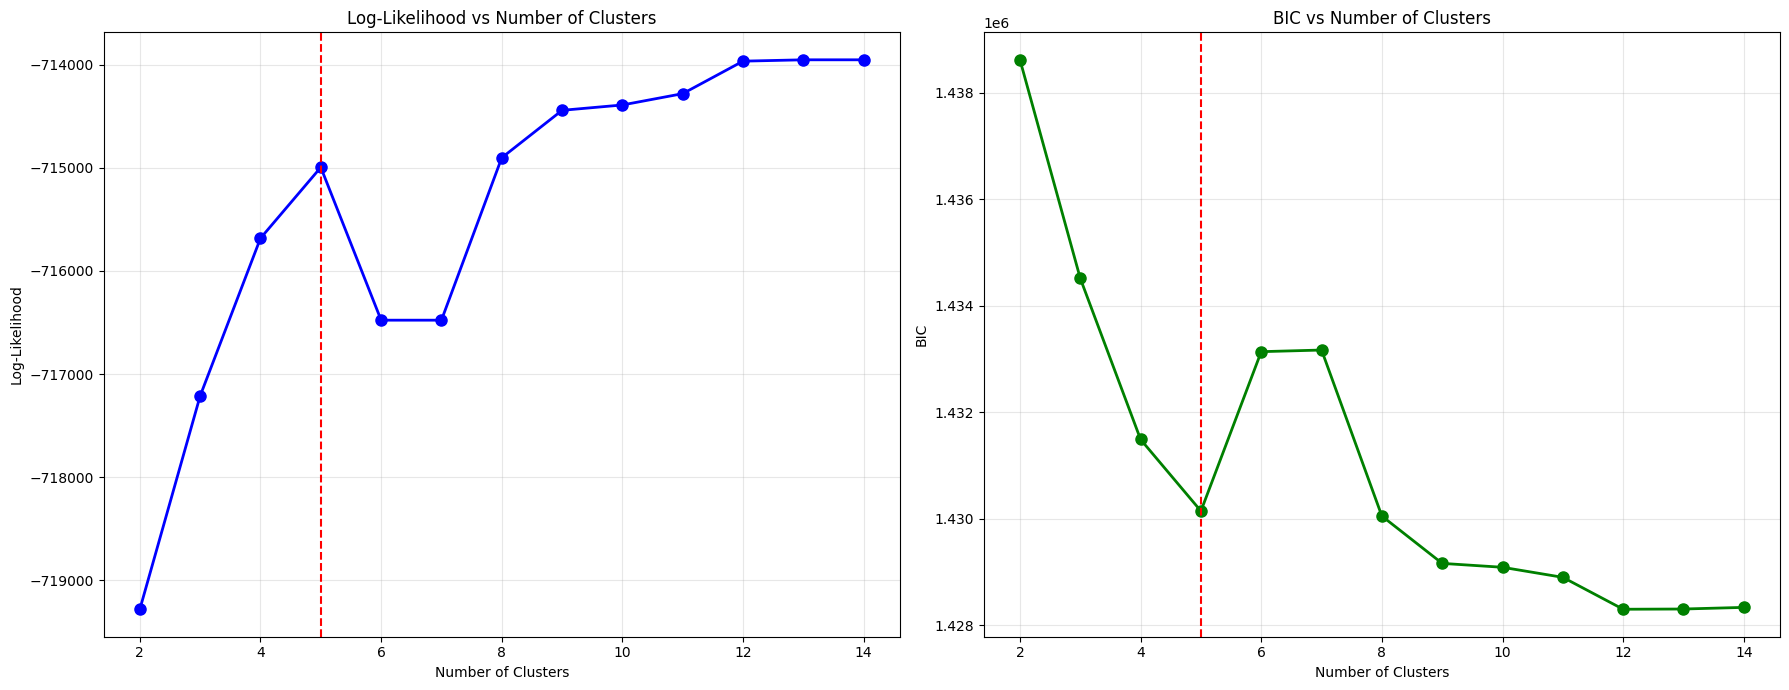

In [42]:
# Plot model comparison
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Log-likelihood
axes[0].plot(comparison_df.index, comparison_df['log_likelihood'], 'bo-', linewidth=2, markersize=8)
axes[0].axvline(5, color='r', linestyle='--')
axes[0].set_xlabel('Number of Clusters')
axes[0].set_ylabel('Log-Likelihood')
axes[0].set_title('Log-Likelihood vs Number of Clusters')
axes[0].grid(True, alpha=0.3)

# # AIC
# axes[1].plot(comparison_df.index, comparison_df['AIC'], 'ro-', linewidth=2, markersize=8)
# axes[1].set_xlabel('Number of Clusters')
# axes[1].set_ylabel('AIC')
# axes[1].set_title('AIC vs Number of Clusters (lower is better)')
# axes[1].grid(True, alpha=0.3)

# BIC
axes[1].plot(comparison_df.index, comparison_df['BIC'], 'go-', linewidth=2, markersize=8)
axes[1].axvline(5, color='r', linestyle='--')
axes[1].set_xlabel('Number of Clusters')
axes[1].set_ylabel('BIC')
axes[1].set_title('BIC vs Number of Clusters')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [50]:
# Run clustering
results = {}
model_comparison = {}

for k in range(4, 15):  # 9 clusters
    print(f"\n{'='*60}")
    print(f"RUNNING {k}-CLUSTER ANALYSIS")
    print(f"{'='*60}")
    
    final_clusters, final_params, history = iterative_likelihood_clustering(
        survival_data, df_params, n_clusters=k
    )
    
    # Store results
    results[k] = {
        'clusters': final_clusters,
        'params': final_params,
        'history': history
    }
    
    # Compute model selection criteria
    total_ll, AIC, BIC, n_params = compute_model_selection_criteria(final_clusters, final_params, k)
    model_comparison[k] = {
        'log_likelihood': total_ll,
        'AIC': AIC,
        'BIC': BIC,
        'n_params': n_params
    }
    
    print(f"\n{k}-CLUSTER FINAL RESULTS:")
    print(f"Total Log-Likelihood: {total_ll:.2f}")
    print(f"AIC: {AIC:.2f}")
    print(f"BIC: {BIC:.2f}")
    
    print(f"\nFinal cluster parameters:")
    for cluster_id, params in final_params.items():
        n_sectors = np.sum(final_clusters == cluster_id)
        sectors_in_cluster = [sector_list[i] for i in range(len(sector_list)) if final_clusters[i] == cluster_id]
        print(f"\nCluster {cluster_id} ({n_sectors} sectors): {sectors_in_cluster}")
        print(f"  mu_ub: {params[0]:.6f}")
        print(f"  mu_lb: {params[1]:.6f}")
        print(f"  K: {params[2]:.6f}")
        print(f"  m: {params[3]:.6f}")


RUNNING 4-CLUSTER ANALYSIS

Initializing 4-cluster analysis with k-means clustering...
Initial cluster assignments:
G: Cluster 2
M: Cluster 2
F: Cluster 0
J: Cluster 2
K: Cluster 1
C: Cluster 0
H: Cluster 3
S: Cluster 1
N: Cluster 1
I: Cluster 1
P: Cluster 0
L: Cluster 2
Q: Cluster 0
R: Cluster 0
Initial cluster parameters:
Cluster 0 (5 sectors): [1.02925738e-01 6.51918672e-02 8.40805924e+00 9.99999854e+01]
Cluster 1 (4 sectors): [1.15262612e-01 2.76704422e-03 1.69598755e+01 6.11533041e+00]
Cluster 2 (4 sectors): [ 0.11255468  0.06431159 10.81970296 30.99241001]
Cluster 3 (1 sectors): [1.90143815e-01 2.80159428e-02 6.93767882e+00 1.00000000e+02]

--- Iteration 1 ---
Likelihood-based assignments:
  G: LL_0=-206404.82, LL_1=-200920.15, LL_2=-201527.81, LL_3=-202992.81 → Cluster 1
  M: LL_0=-107360.67, LL_1=-107195.64, LL_2=-106969.75, LL_3=-111821.22 → Cluster 2
  F: LL_0=-48082.90, LL_1=-49338.65, LL_2=-48852.26, LL_3=-51992.48 → Cluster 0
  J: LL_0=-58535.25, LL_1=-57386.75, LL_2=-575

KeyboardInterrupt: 

In [ ]:
# random initial guesses to test for robustness
def robust_parallel_clustering(survival_data, df_params, n_clusters=2, n_trials=30, n_jobs=-2):
    """
    Runs multiple EM clustering trials in parallel to find the global optimum.
    """
    
    def single_trial(trial_id):
        # 1. Set a unique random seed for this specific CPU thread
        np.random.seed(trial_id + int(time.time() % 1000)) 
        
        # 2. Generate random starting parameters within your MLE bounds
        random_init_params = {}
        for c in range(n_clusters):
            # --- IMPORTANT: Ensure these match the bounds in your MLE function ---
            mu_ub = np.random.uniform(1e-6, 0.3)
            mu_lb = np.random.uniform(1e-6, min(mu_ub, 0.15) - 1e-7) # strictly < mu_ub
            K = np.random.uniform(0.1, 50.0)
            m = np.random.uniform(0.1, 100.0)
            # ---------------------------------------------------------------------
            
            random_init_params[c] = np.array([mu_ub, mu_lb, K, m])
            
        # 3. Run your modified EM algorithm with these random starts
        try:
            clusters, params, history = iterative_likelihood_clustering(
                survival_data, 
                df_params, 
                n_clusters=n_clusters, 
                init_params=random_init_params, 
                verbose=False
            )
            final_ll = history['total_likelihood'][-1]
            return final_ll, clusters, params
            
        except Exception as e:
            # If a random start causes math errors or SLSQP fails, safely ignore it
            return -np.inf, None, None

    print(f"Starting {n_trials} parallel trials using {n_jobs if n_jobs > 0 else 'most'} CPU cores...")
    start_time = time.time()
    
    # 4. Execute the trials in parallel
    results = Parallel(n_jobs=n_jobs)(
        delayed(single_trial)(i) for i in range(n_trials)
    )
    
    # 5. Find the absolute best trial
    best_ll = -np.inf
    best_clusters = None
    best_params = None
    
    for ll, clusters, params in results:
        if ll > best_ll:
            best_ll = ll
            best_clusters = clusters
            best_params = params
            
    elapsed = time.time() - start_time
    print(f"Optimization complete in {elapsed:.1f} seconds.")
    print(f"Best Global Log-Likelihood found: {best_ll:.3f}")
    
    return best_clusters, best_params

In [9]:
# --- RUN THE ROBUST CLUSTERING ---
for k in range(3, 13):
    print(f"--- Running Robust Multi-Start Clustering for K={k} ---")
    best_clusters, best_params = robust_parallel_clustering(
        survival_data=survival_data, 
        df_params=df_params, 
        n_clusters=k, 
        n_trials=30, 
        n_jobs=3  
    )

    # --- VIEW THE FINAL WINNING RESULTS ---
    print("\n=== FINAL ROBUST CLUSTERS ===")
    for i, sector in enumerate(sector_list):
        print(f"Sector {sector}: Cluster {best_clusters[i]}")

    print("\n=== FINAL ROBUST PARAMETERS ===")
    for cluster_id, params in best_params.items():
        n_in_cluster = np.sum(best_clusters == cluster_id)
        print(f"Cluster {cluster_id} ({n_in_cluster} sectors):")
        print(f"  mu_ub: {params[0]:.6f}")
        print(f"  mu_lb: {params[1]:.6f}")
        print(f"  K:     {params[2]:.4f}")
        print(f"  m:     {params[3]:.4f}")

    # Optional: Compute AIC/BIC on your winning model to see if 5 clusters is actually the right number
    total_ll, AIC, BIC, n_params = compute_model_selection_criteria(best_clusters, best_params, k)
    print(f"\nModel Selection Criteria (K={k}):")
    print(f"  Total LL: {total_ll:.2f}")
    print(f"  AIC:      {AIC:.2f}")
    print(f"  BIC:      {BIC:.2f}")

--- Running Robust Multi-Start Clustering for K=3 ---
Starting 30 parallel trials using 3 CPU cores...
Optimization complete in 440.5 seconds.
Best Global Log-Likelihood found: -717211.552

=== FINAL ROBUST CLUSTERS ===
Sector G: Cluster 0
Sector M: Cluster 0
Sector F: Cluster 2
Sector J: Cluster 0
Sector K: Cluster 2
Sector C: Cluster 2
Sector H: Cluster 1
Sector S: Cluster 0
Sector N: Cluster 0
Sector I: Cluster 0
Sector P: Cluster 0
Sector L: Cluster 2
Sector Q: Cluster 2
Sector R: Cluster 0

=== FINAL ROBUST PARAMETERS ===
Cluster 0 (8 sectors):
  mu_ub: 0.127760
  mu_lb: 0.042356
  K:     12.1964
  m:     41.9867
Cluster 1 (1 sectors):
  mu_ub: 0.198700
  mu_lb: 0.027106
  K:     6.8943
  m:     100.0000
Cluster 2 (5 sectors):
  mu_ub: 0.080962
  mu_lb: 0.046938
  K:     15.2274
  m:     3.4782

Model Selection Criteria (K=3):
  Total LL: -717211.55
  AIC:      1434447.10
  BIC:      1434514.90
--- Running Robust Multi-Start Clustering for K=4 ---
Starting 30 parallel trials using

KeyboardInterrupt: 

In [4]:
def kmeans_jitter_clustering(survival_data, df_params, n_clusters=2, n_trials=30, n_jobs=-2, jitter_fraction=0.20):
    """
    Runs parallel EM trials by taking the K-means centroids and applying 
    percentage-based random jitter to test the stability of the local optimum.
    """
    n_sectors = len(survival_data)
    
    print(f"--- Step 1: Calculating Base K-Means Centroids ---")
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df_params.values)
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    initial_clusters = kmeans.fit_predict(X_scaled)
    
    # Extract the base parameters for each cluster
    base_centroids = {}
    for cluster_id in range(n_clusters):
        mask = initial_clusters == cluster_id
        if np.any(mask):
            base_centroids[cluster_id] = df_params.values[mask].mean(axis=0)
        else:
            base_centroids[cluster_id] = df_params.values[np.random.randint(0, n_sectors)]
            
    print(f"--- Step 2: Running {n_trials} Jittered Trials (±{jitter_fraction*100}%) ---")
    
    def single_trial(trial_id):
        np.random.seed(trial_id + int(time.time() % 1000))
        
        jittered_params = {}
        for c, base_param in base_centroids.items():
            # Apply random percentage shift between (1 - jitter) and (1 + jitter)
            # e.g., for 0.20 jitter, multiply by a random number between 0.8 and 1.2
            noise_multiplier = np.random.uniform(1 - jitter_fraction, 1 + jitter_fraction, size=4)
            p_noisy = base_param * noise_multiplier
            
            # Unpack and enforce strict model bounds/constraints
            mu_ub = np.clip(p_noisy[0], 1e-6, 0.3)
            mu_lb = np.clip(p_noisy[1], 1e-6, mu_ub - 1e-6) # Must be < mu_ub
            K = np.clip(p_noisy[2], 0.1, 50.0)
            m = np.clip(p_noisy[3], 0.1, 100.0)
            
            jittered_params[c] = np.array([mu_ub, mu_lb, K, m])
            
        try:
            # Pass these slightly perturbed parameters into your EM algorithm
            clusters, params, history = iterative_likelihood_clustering(
                survival_data, 
                df_params, 
                n_clusters=n_clusters, 
                init_params=jittered_params, 
                verbose=False 
            )
            final_ll = history['total_likelihood'][-1]
            return final_ll, clusters, params
        except Exception:
            return -np.inf, None, None

    # Run parallel execution
    start_time = time.time()
    results = Parallel(n_jobs=n_jobs)(delayed(single_trial)(i) for i in range(n_trials))
    
    # Find the best valid result
    best_ll = -np.inf
    best_clusters, best_params = None, None
    
    for ll, clusters, params in results:
        if ll > best_ll:
            best_ll = ll
            best_clusters = clusters
            best_params = params
            
    print(f"Optimization complete in {time.time() - start_time:.1f} seconds.")
    print(f"Best Jittered Log-Likelihood: {best_ll:.3f}")
    
    return best_clusters, best_params

Starting evaluation for K=2 to K=14...

Evaluating K=2...
--- Step 1: Calculating Base K-Means Centroids ---
--- Step 2: Running 15 Jittered Trials (±15.0%) ---
Optimization complete in 1110.4 seconds.
Best Jittered Log-Likelihood: -720572.009
  Result K=2: LL=-720572.01, AIC=1441160.02, BIC=1441205.22

Evaluating K=3...
--- Step 1: Calculating Base K-Means Centroids ---
--- Step 2: Running 15 Jittered Trials (±15.0%) ---
Optimization complete in 1334.3 seconds.
Best Jittered Log-Likelihood: -720572.009
  Result K=3: LL=-720572.01, AIC=1441168.02, BIC=1441235.81

Evaluating K=4...
--- Step 1: Calculating Base K-Means Centroids ---
--- Step 2: Running 15 Jittered Trials (±15.0%) ---
Optimization complete in 1354.6 seconds.
Best Jittered Log-Likelihood: -718181.495
  Result K=4: LL=-718181.50, AIC=1436394.99, BIC=1436485.39

Evaluating K=5...
--- Step 1: Calculating Base K-Means Centroids ---
--- Step 2: Running 15 Jittered Trials (±15.0%) ---
Optimization complete in 756.5 seconds.
Best

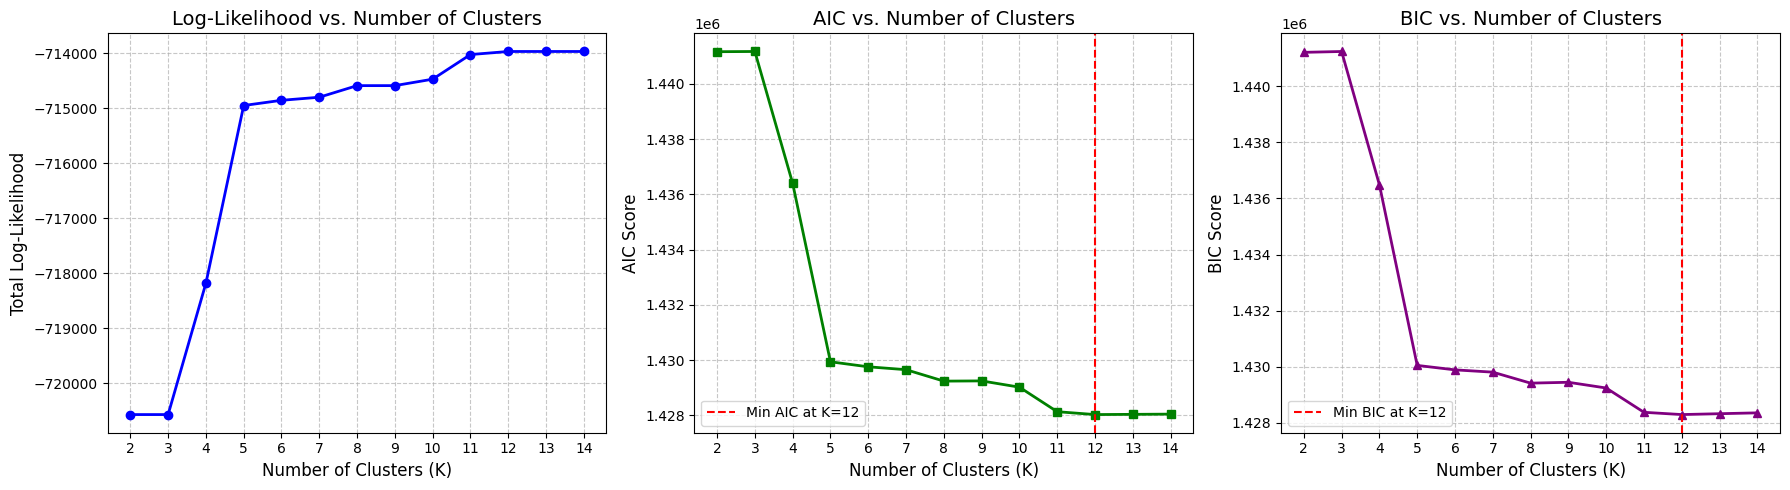


According to AIC, the optimal number of clusters is: 12
According to BIC, the optimal number of clusters is: 12


In [5]:
# --- 1. SETUP STORAGE FOR METRICS ---
k_values = list(range(2, 15))  # 2 through 14
ll_scores = []
aic_scores = []
bic_scores = []

# Optional: store the best models so you don't have to re-run them later
best_models = {}

print(f"Starting evaluation for K={min(k_values)} to K={max(k_values)}...")
total_start_time = time.time()

# --- 2. RUN THE LOOP ---
for k in k_values:
    print(f"\nEvaluating K={k}...")
    
    # Run the jittered K-means clustering
    clusters, params = kmeans_jitter_clustering(
        survival_data=survival_data, 
        df_params=df_params, 
        n_clusters=k, 
        n_trials=15,     # Number of random jitters per K
        n_jobs=-1,
        jitter_fraction=0.15
    )
    
    # Compute the selection criteria
    total_ll, aic, bic, n_params = compute_model_selection_criteria(clusters, params, k)
    
    # Record the results
    ll_scores.append(total_ll)
    aic_scores.append(aic)
    bic_scores.append(bic)
    
    # Save the model in case you want to access the best one later
    best_models[k] = {
    'clusters': clusters,
    'params': params,
    'log_likelihood': total_ll,
    'AIC': aic,
    'BIC': bic,
    'n_params': n_params
    }
    
    print(f"  Result K={k}: LL={total_ll:.2f}, AIC={aic:.2f}, BIC={bic:.2f}")

print(f"\nAll K values evaluated in {(time.time() - total_start_time)/60:.1f} minutes.")

# --- 3. PLOTTING THE RESULTS ---

# Create a figure with 3 separate subplots side-by-side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Log-Likelihood
axes[0].plot(k_values, ll_scores, marker='o', color='blue', linewidth=2)
axes[0].set_title('Log-Likelihood vs. Number of Clusters', fontsize=14)
axes[0].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[0].set_ylabel('Total Log-Likelihood', fontsize=12)
axes[0].set_xticks(k_values)
axes[0].grid(True, linestyle='--', alpha=0.7)

# Plot 2: AIC (Akaike Information Criterion)
axes[1].plot(k_values, aic_scores, marker='s', color='green', linewidth=2)
# Highlight the minimum AIC
best_k_aic = k_values[np.argmin(aic_scores)]
axes[1].axvline(best_k_aic, color='red', linestyle='--', label=f'Min AIC at K={best_k_aic}')
axes[1].set_title('AIC vs. Number of Clusters', fontsize=14)
axes[1].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[1].set_ylabel('AIC Score', fontsize=12)
axes[1].set_xticks(k_values)
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.7)

# Plot 3: BIC (Bayesian Information Criterion)
axes[2].plot(k_values, bic_scores, marker='^', color='purple', linewidth=2)
# Highlight the minimum BIC
best_k_bic = k_values[np.argmin(bic_scores)]
axes[2].axvline(best_k_bic, color='red', linestyle='--', label=f'Min BIC at K={best_k_bic}')
axes[2].set_title('BIC vs. Number of Clusters', fontsize=14)
axes[2].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[2].set_ylabel('BIC Score', fontsize=12)
axes[2].set_xticks(k_values)
axes[2].legend()
axes[2].grid(True, linestyle='--', alpha=0.7)

# Adjust layout and show the plots
plt.tight_layout()
plt.show()

print(f"\nAccording to AIC, the optimal number of clusters is: {best_k_aic}")
print(f"According to BIC, the optimal number of clusters is: {best_k_bic}")

In [6]:
import pandas as pd

sector_list = ['G', 'M', 'F', 'J', 'K', 'C', 'H', 'S', 'N', 'I', 'P', 'L', 'Q', 'R']

# ---------------------------------------------------------
# 1. Save Sector Assignments (Rows = Sectors, Columns = K)
# ---------------------------------------------------------
# This will show you exactly how each sector jumped around as K increased
assignments_dict = {'Sector': sector_list}

for k in k_values:
    # Extract the cluster array for this K
    assignments_dict[f'Cluster_K{k}'] = best_models[k]['clusters']

df_assignments = pd.DataFrame(assignments_dict)
df_assignments.to_csv('outputs/cluster_assignments_history.csv', index=False)
print("Saved sector assignments to 'outputs/cluster_assignments_history.csv'")

# ---------------------------------------------------------
# 2. Save Model Fit Metrics (Rows = K, Columns = AIC/BIC/LL)
# ---------------------------------------------------------
# This saves the data used to generate your plots
metrics_list = []

for k in k_values:
    metrics_list.append({
        'K': k,
        'Log_Likelihood': best_models[k]['log_likelihood'],
        'AIC': best_models[k]['AIC'],
        'BIC': best_models[k]['BIC'],
        'n_params': best_models[k]['n_params']
    })

df_metrics = pd.DataFrame(metrics_list)
df_metrics.to_csv('outputs/model_fit_metrics.csv', index=False)
print("Saved model metrics to 'outputs/model_fit_metrics.csv'")

# ---------------------------------------------------------
# 3. Save Cluster Parameters (Rows = Cluster IDs, Columns = Parameters)
# ---------------------------------------------------------
# This saves the actual Hill function parameters for every cluster in every K
params_list = []

for k in k_values:
    for cluster_id, params in best_models[k]['params'].items():
        params_list.append({
            'K': k,
            'Cluster_ID': cluster_id,
            'mu_ub': params[0],
            'mu_lb': params[1],
            'K_param': params[2], # Renamed to avoid confusion with cluster K
            'm_param': params[3]
        })

df_params_export = pd.DataFrame(params_list)
df_params_export.to_csv('outputs/cluster_hill_parameters.csv', index=False)
print("Saved cluster parameters to 'outputs/cluster_hill_parameters.csv'")

Saved sector assignments to 'cluster_assignments_history.csv'
Saved model metrics to 'model_fit_metrics.csv'
Saved cluster parameters to 'cluster_hill_parameters.csv'


In [10]:
# --- 1. SETUP STORAGE FOR METRICS ---
k_values = list(range(4, 7))
ll_scores = []
aic_scores = []
bic_scores = []

# Optional: store the best models so you don't have to re-run them later
best_models = {}

print(f"Starting evaluation for K={min(k_values)} to K={max(k_values)}...")
total_start_time = time.time()

# --- 2. RUN THE LOOP ---
for k in k_values:
    print(f"\nEvaluating K={k}...")
    
    # Run the jittered K-means clustering
    clusters, params = kmeans_jitter_clustering(
        survival_data=survival_data, 
        df_params=df_params, 
        n_clusters=k, 
        n_trials=15,     # Number of random jitters per K
        n_jobs=-1,
        jitter_fraction=0.15
    )
    
    # Compute the selection criteria
    total_ll, aic, bic, n_params = compute_model_selection_criteria(clusters, params, k)
    
    # Record the results
    ll_scores.append(total_ll)
    aic_scores.append(aic)
    bic_scores.append(bic)
    
    # Save the model in case you want to access the best one later
    best_models[k] = {'clusters': clusters, 'params': params}
    
    print(f"  Result K={k}: LL={total_ll:.2f}, AIC={aic:.2f}, BIC={bic:.2f}")

print(f"\nAll K values evaluated in {(time.time() - total_start_time)/60:.1f} minutes.")

Starting evaluation for K=4 to K=6...

Evaluating K=4...
--- Step 1: Calculating Base K-Means Centroids ---
--- Step 2: Running 15 Jittered Trials (±15.0%) ---
Optimization complete in 1916.6 seconds.
Best Jittered Log-Likelihood: -718181.495
  Result K=4: LL=-718181.50, AIC=1436394.99, BIC=1436485.39

Evaluating K=5...
--- Step 1: Calculating Base K-Means Centroids ---
--- Step 2: Running 15 Jittered Trials (±15.0%) ---
Optimization complete in 1883.2 seconds.
Best Jittered Log-Likelihood: -714949.135
  Result K=5: LL=-714949.14, AIC=1429938.27, BIC=1430051.26

Evaluating K=6...
--- Step 1: Calculating Base K-Means Centroids ---
--- Step 2: Running 15 Jittered Trials (±15.0%) ---
Optimization complete in 38412.0 seconds.
Best Jittered Log-Likelihood: -714854.344
  Result K=6: LL=-714854.34, AIC=1429756.69, BIC=1429892.28

All K values evaluated in 704.3 minutes.


In [13]:
# display best_models
def print_model_summary(k, model, sector_list):
    clusters = np.asarray(model['clusters']).astype(int)
    params = model['params']

    print(f"\nBest model for K={k}")
    print("\nFinal cluster parameters:")

    for cluster_id in sorted(set(clusters)):
        sectors_in_cluster = [
            sector for sector, c in zip(sector_list, clusters) if c == cluster_id
        ]
        p = params[cluster_id]

        print(f"\nCluster {cluster_id} ({len(sectors_in_cluster)} sectors): {sectors_in_cluster}")
        print(f"  mu_ub: {p[0]:.6f}")
        print(f"  mu_lb: {p[1]:.6f}")
        print(f"  K: {p[2]:.6f}")
        print(f"  m: {p[3]:.6f}")

for k, model in best_models.items():
    print_model_summary(k, model, sector_list)


Best model for K=4

Final cluster parameters:

Cluster 0 (7 sectors): ['G', 'M', 'J', 'H', 'S', 'N', 'P']
  mu_ub: 0.133910
  mu_lb: 0.000001
  K: 15.525581
  m: 3.156042

Cluster 1 (2 sectors): ['K', 'Q']
  mu_ub: 0.072668
  mu_lb: 0.025375
  K: 15.185550
  m: 13.950078

Cluster 2 (3 sectors): ['F', 'C', 'L']
  mu_ub: 0.085131
  mu_lb: 0.065720
  K: 10.064845
  m: 66.940298

Cluster 3 (2 sectors): ['I', 'R']
  mu_ub: 0.134740
  mu_lb: 0.037681
  K: 15.970805
  m: 2.929047

Best model for K=5

Final cluster parameters:

Cluster 0 (3 sectors): ['F', 'C', 'L']
  mu_ub: 0.085131
  mu_lb: 0.065720
  K: 10.064845
  m: 66.940298

Cluster 1 (2 sectors): ['K', 'Q']
  mu_ub: 0.072668
  mu_lb: 0.025375
  K: 15.185550
  m: 13.950078

Cluster 2 (1 sectors): ['H']
  mu_ub: 0.198700
  mu_lb: 0.027106
  K: 6.894266
  m: 100.000000

Cluster 3 (7 sectors): ['G', 'J', 'S', 'N', 'I', 'P', 'R']
  mu_ub: 0.137680
  mu_lb: 0.000001
  K: 15.674876
  m: 3.047387

Cluster 4 (1 sectors): ['M']
  mu_ub: 0.11388

In [ ]:
# --- 3. PLOTTING THE RESULTS ---

# Create a figure with 3 separate subplots side-by-side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Log-Likelihood
axes[0].plot(k_values, ll_scores, marker='o', color='blue', linewidth=2)
axes[0].set_title('Log-Likelihood vs. Number of Clusters', fontsize=14)
axes[0].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[0].set_ylabel('Total Log-Likelihood', fontsize=12)
axes[0].set_xticks(k_values)
axes[0].grid(True, linestyle='--', alpha=0.7)

# Plot 2: AIC (Akaike Information Criterion)
axes[1].plot(k_values, aic_scores, marker='s', color='green', linewidth=2)
# Highlight the minimum AIC
best_k_aic = k_values[np.argmin(aic_scores)]
axes[1].axvline(best_k_aic, color='red', linestyle='--', label=f'Min AIC at K={best_k_aic}')
axes[1].set_title('AIC vs. Number of Clusters', fontsize=14)
axes[1].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[1].set_ylabel('AIC Score', fontsize=12)
axes[1].set_xticks(k_values)
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.7)

# Plot 3: BIC (Bayesian Information Criterion)
axes[2].plot(k_values, bic_scores, marker='^', color='purple', linewidth=2)
# Highlight the minimum BIC
best_k_bic = k_values[np.argmin(bic_scores)]
axes[2].axvline(best_k_bic, color='red', linestyle='--', label=f'Min BIC at K={best_k_bic}')
axes[2].set_title('BIC vs. Number of Clusters', fontsize=14)
axes[2].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[2].set_ylabel('BIC Score', fontsize=12)
axes[2].set_xticks(k_values)
axes[2].legend()
axes[2].grid(True, linestyle='--', alpha=0.7)

# Adjust layout and show the plots
plt.tight_layout()
plt.show()

print(f"\nAccording to AIC, the optimal number of clusters is: {best_k_aic}")
print(f"According to BIC, the optimal number of clusters is: {best_k_bic}")

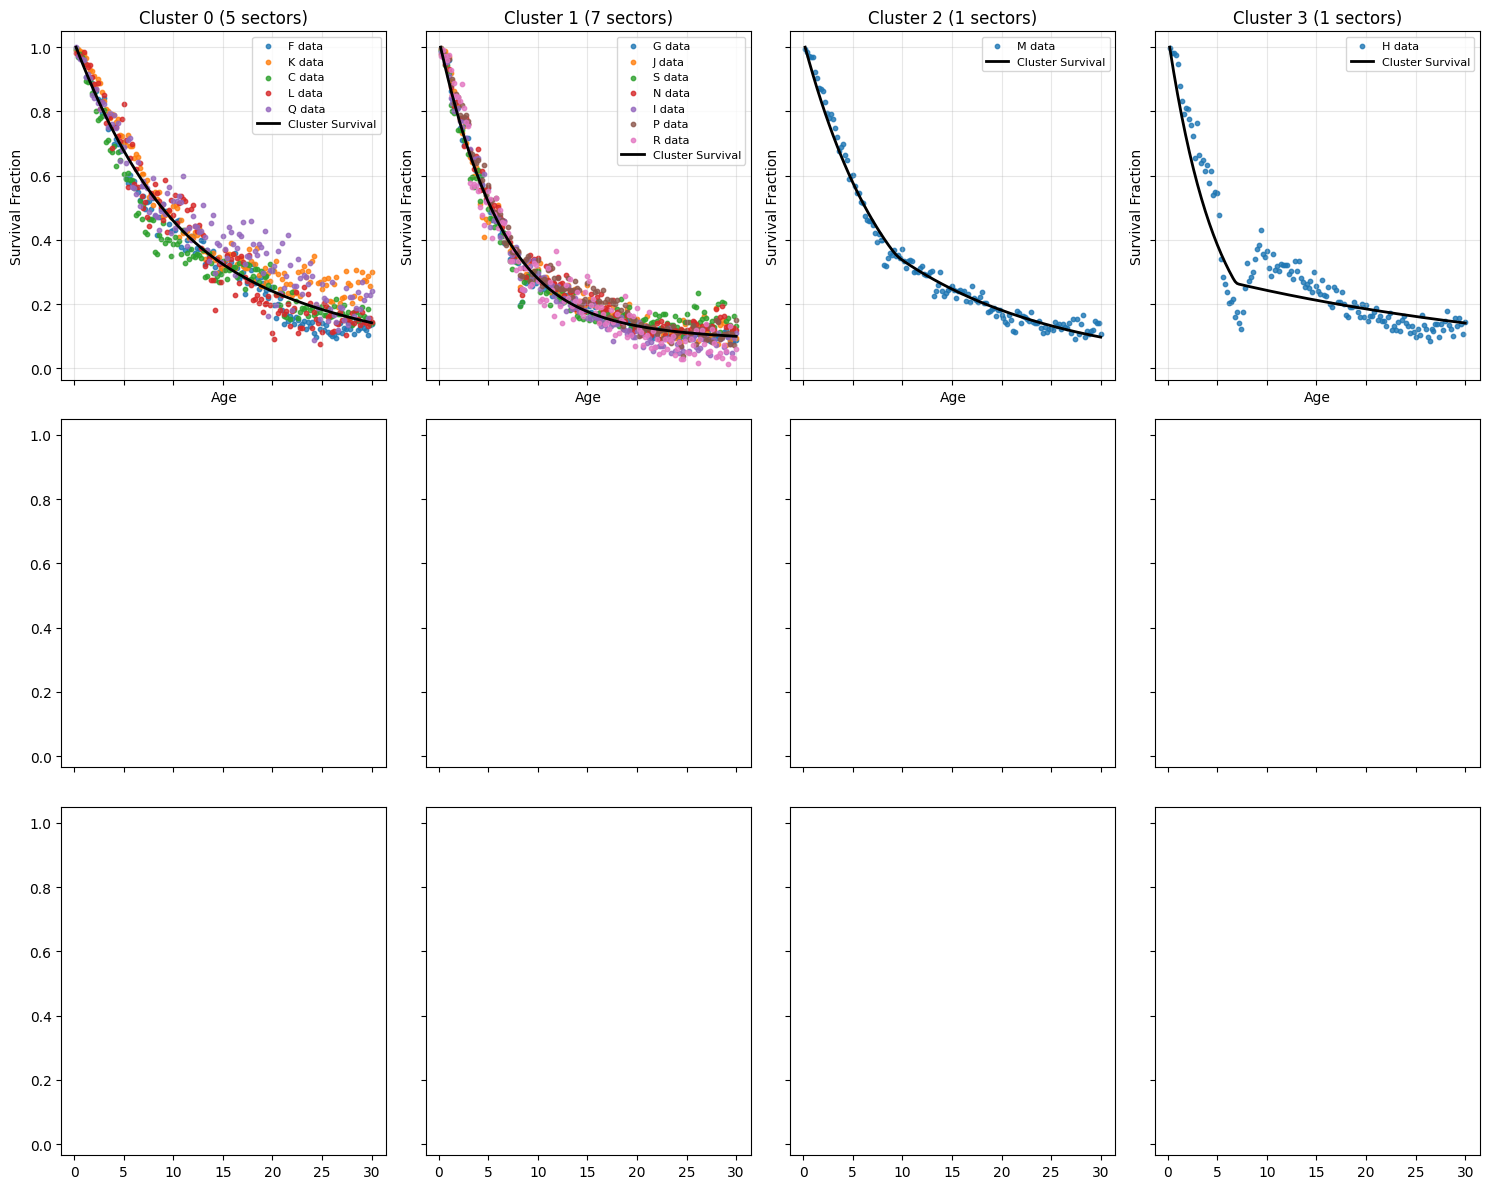

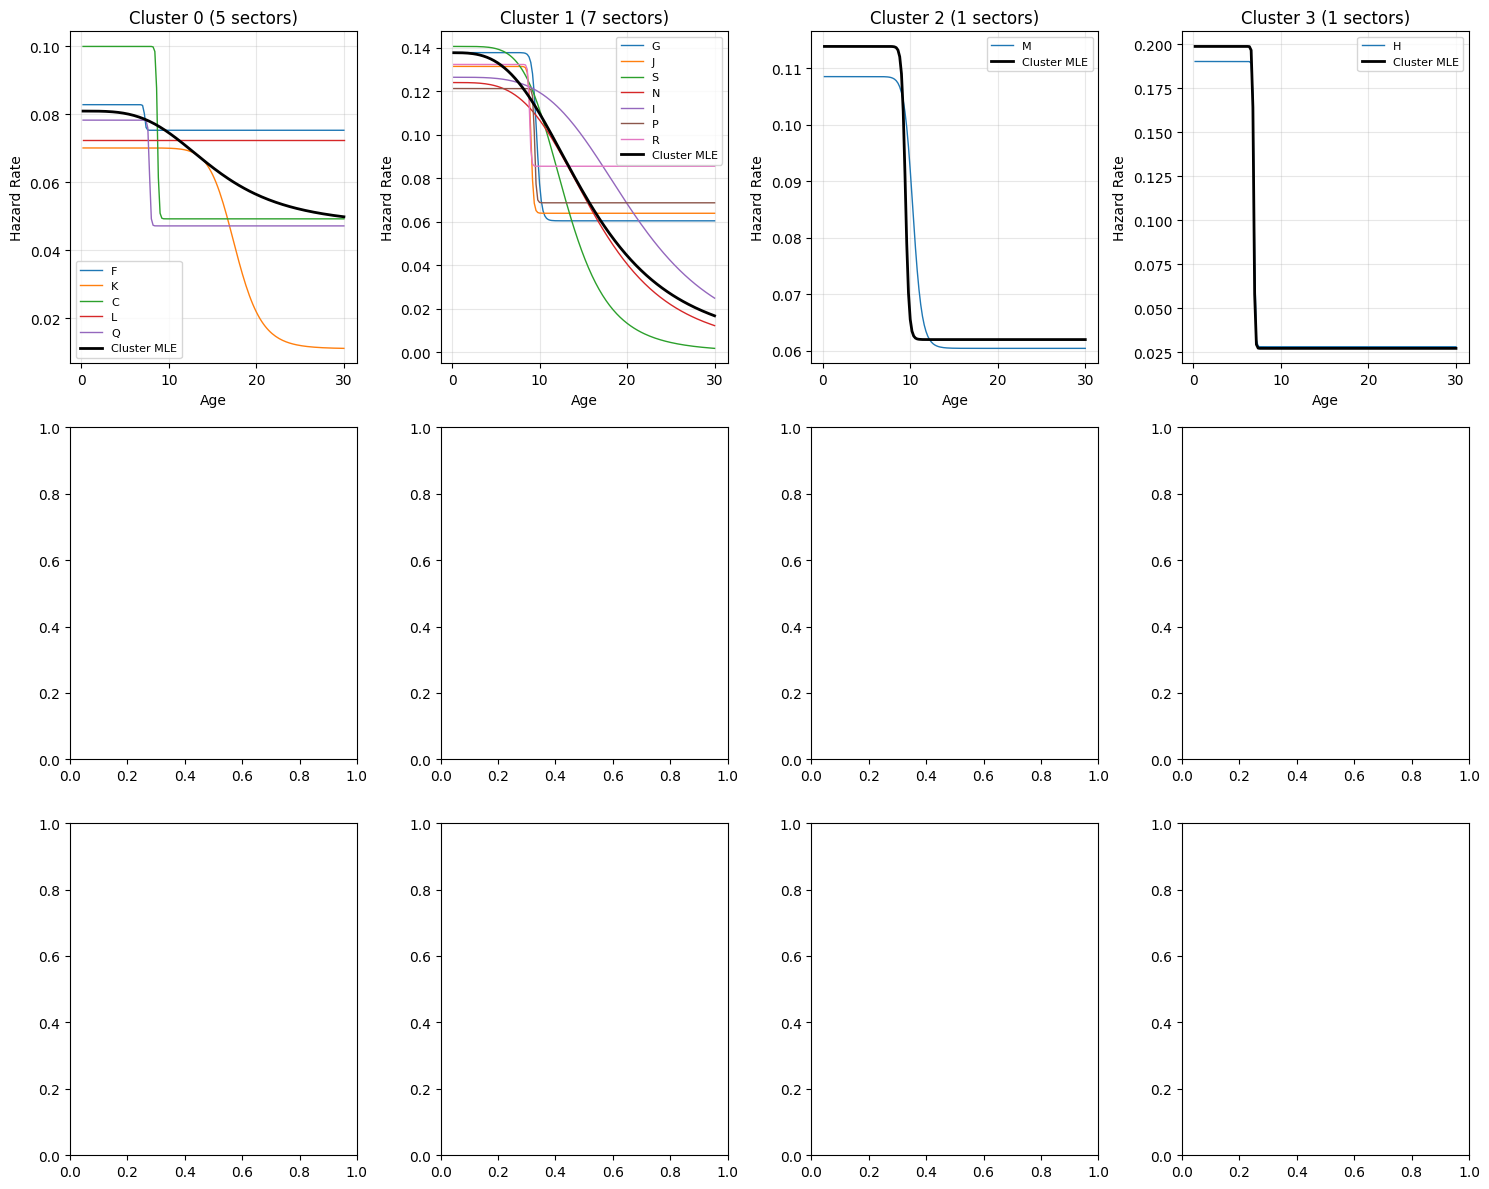

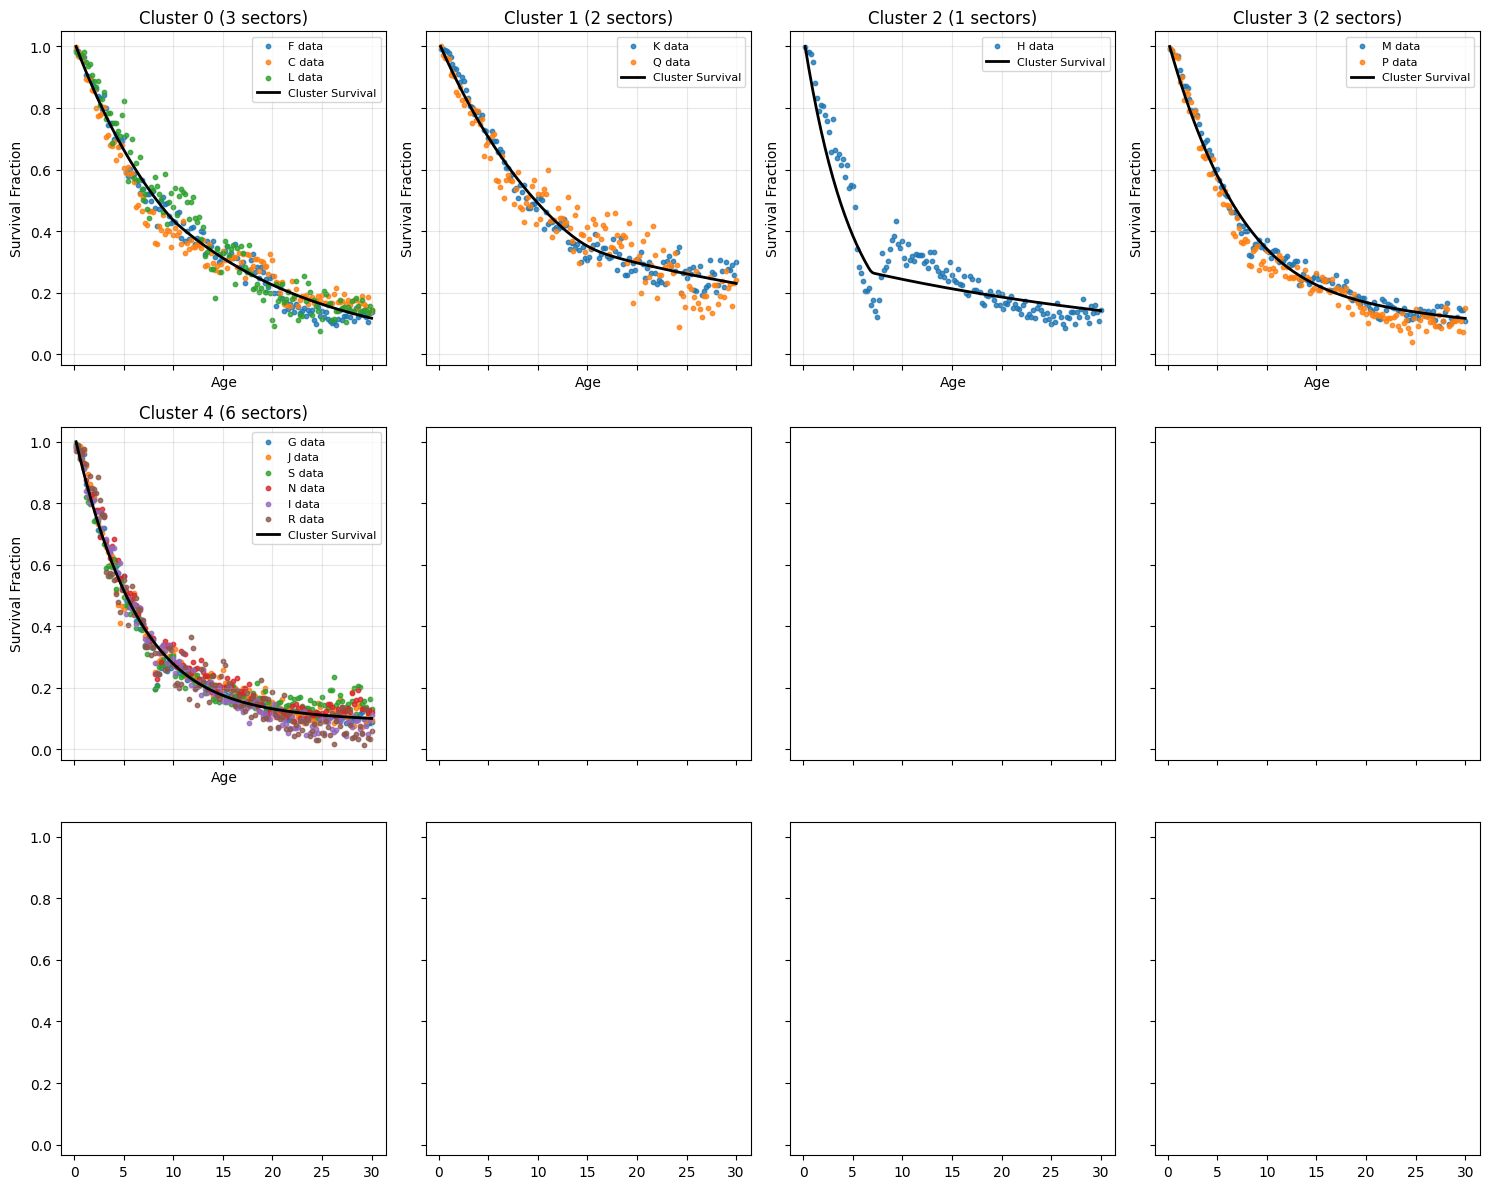

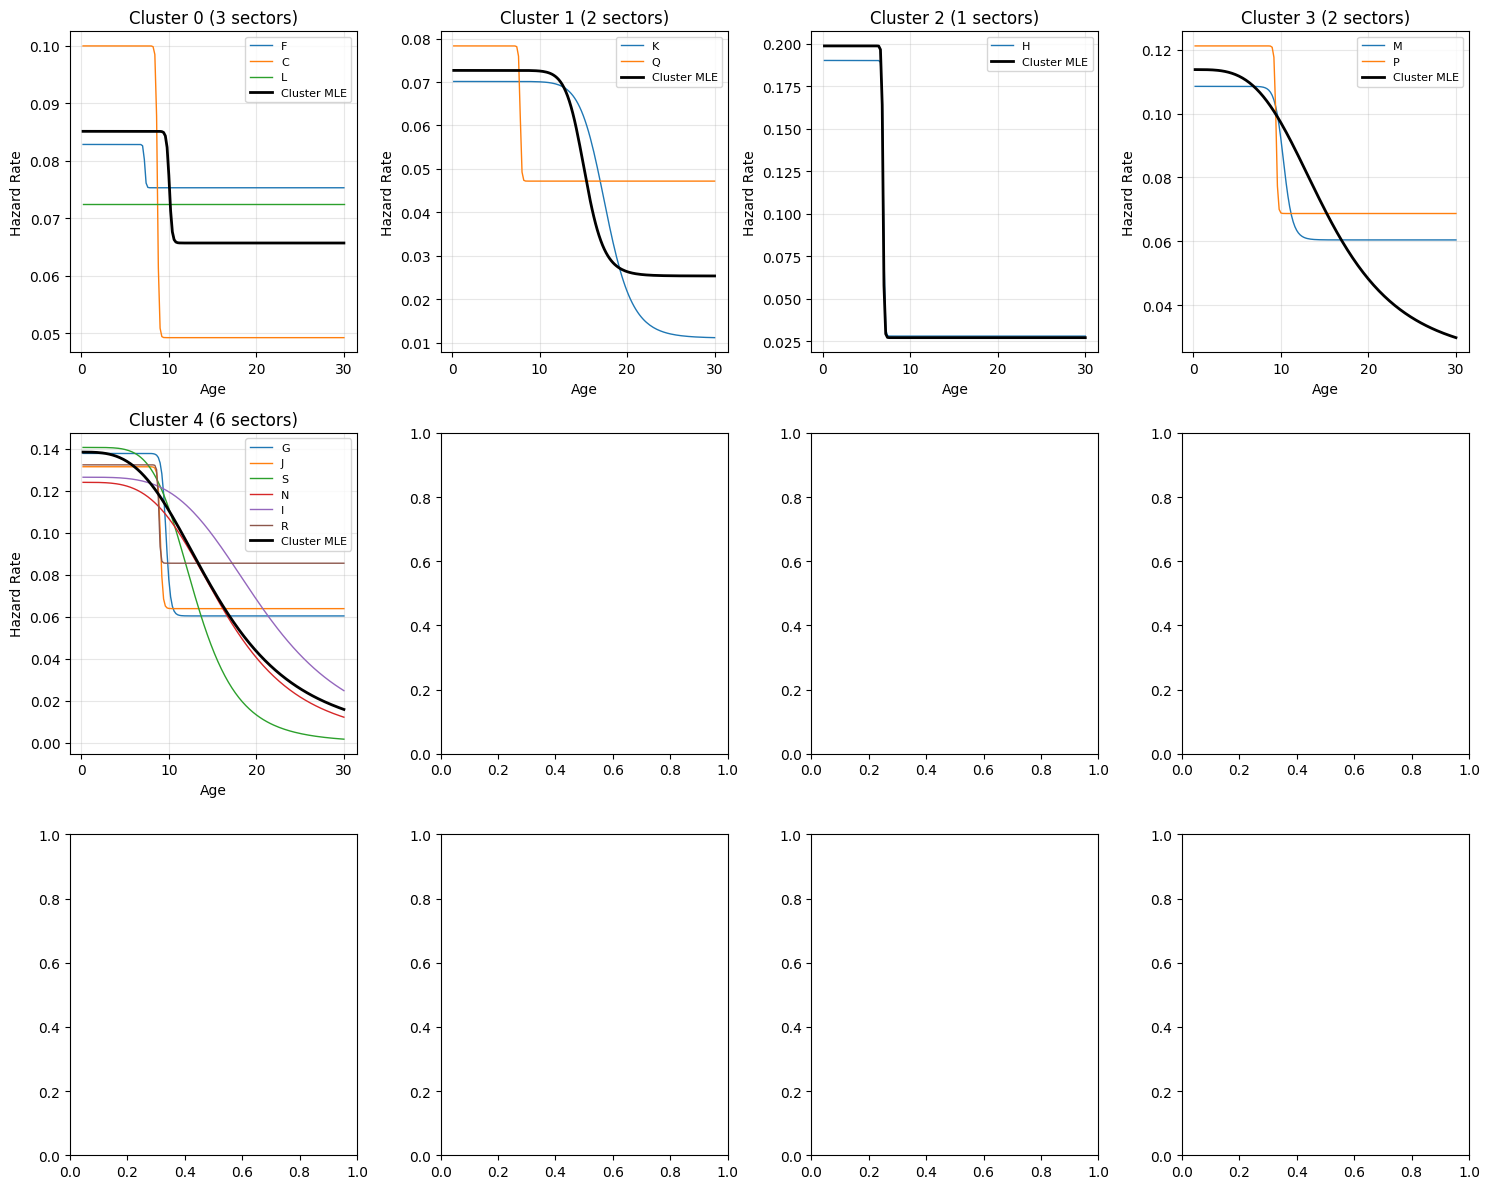

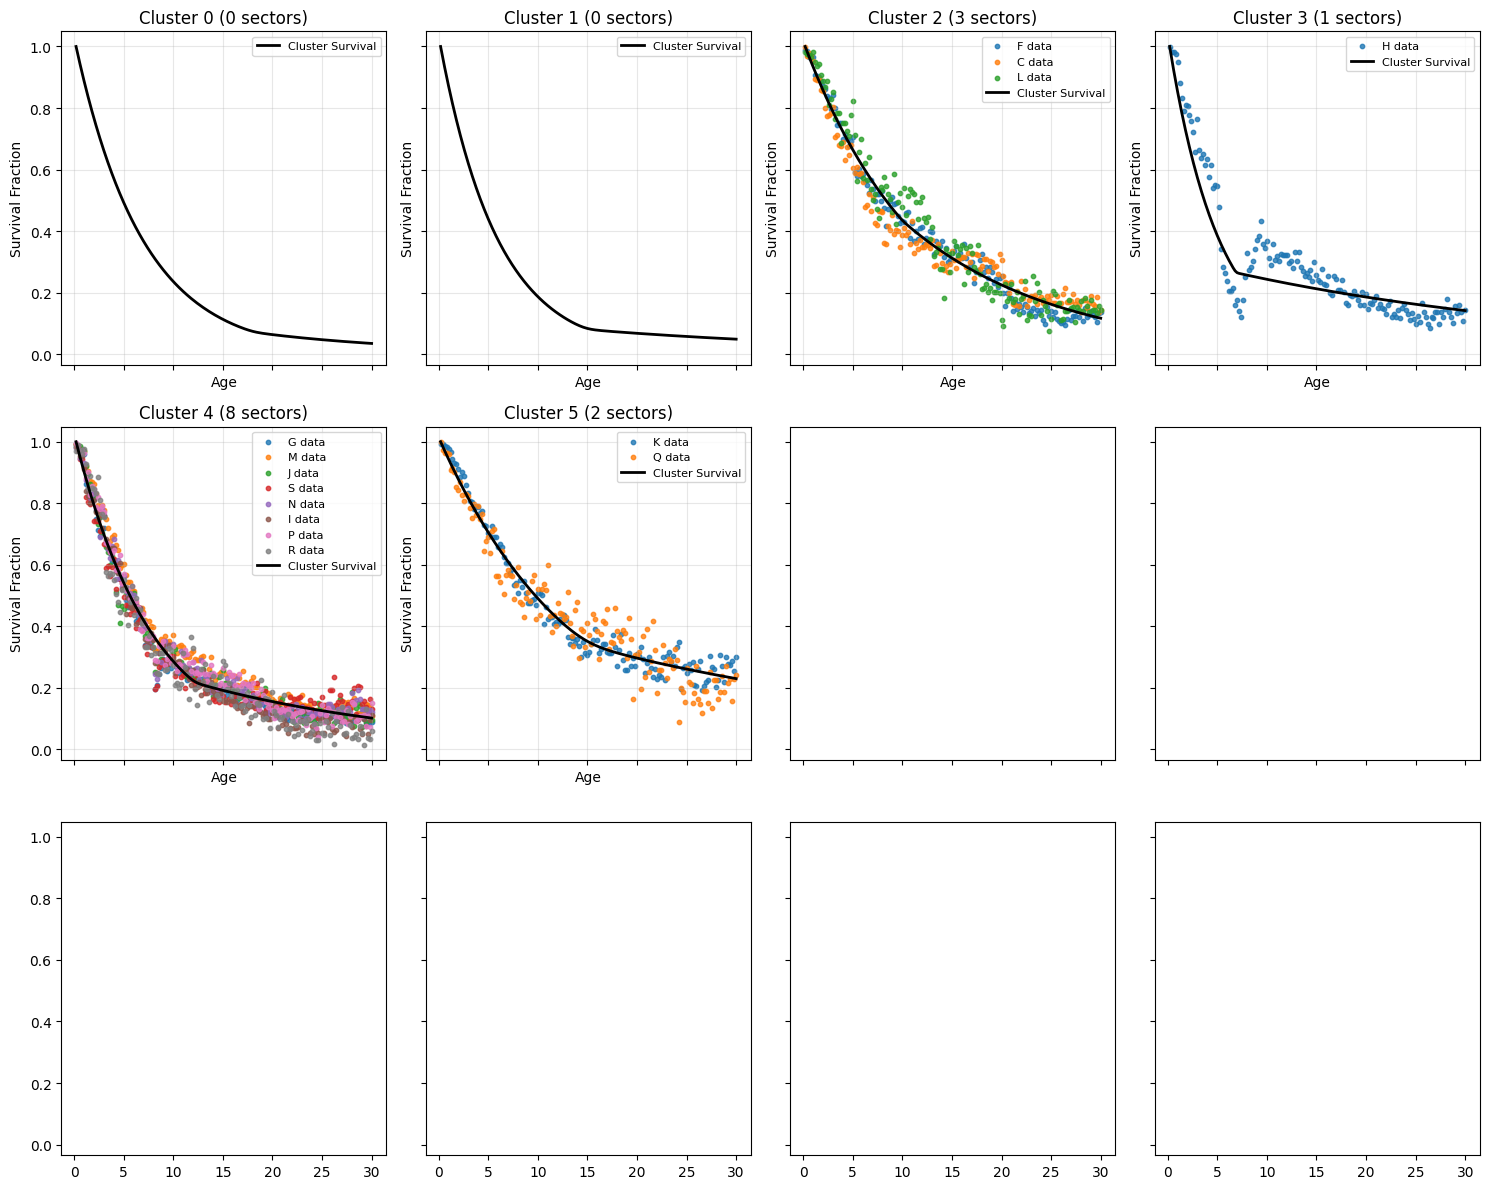

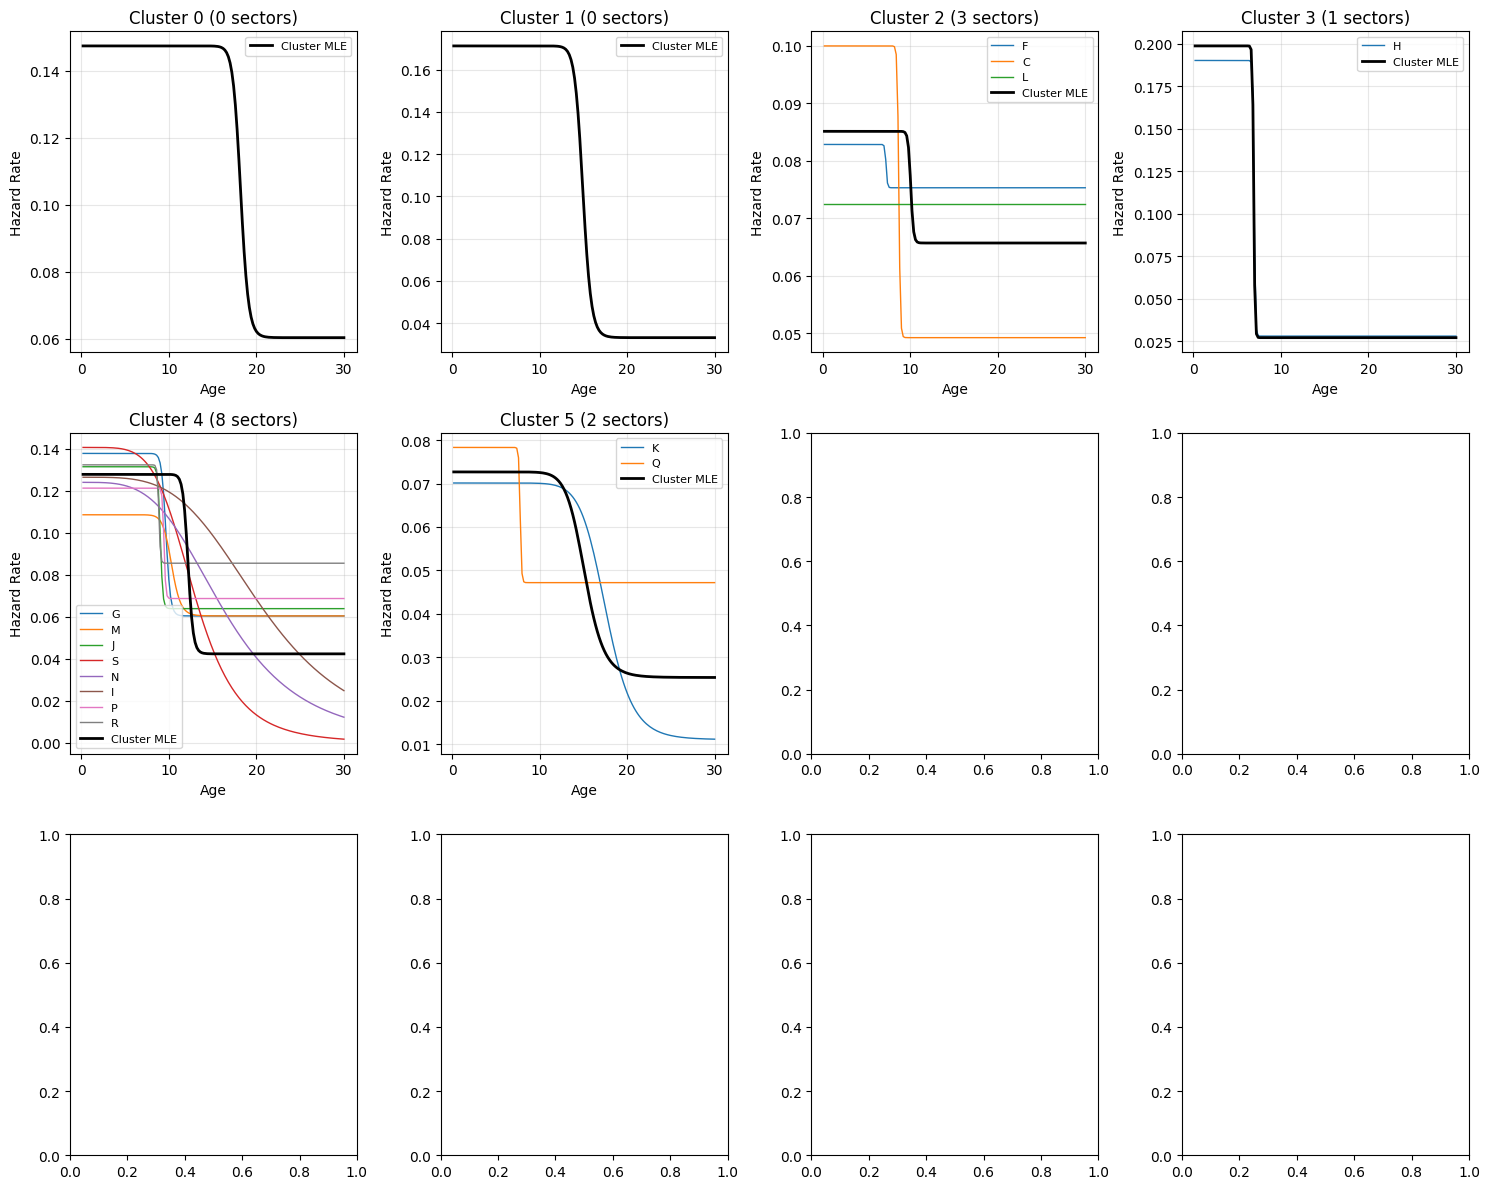

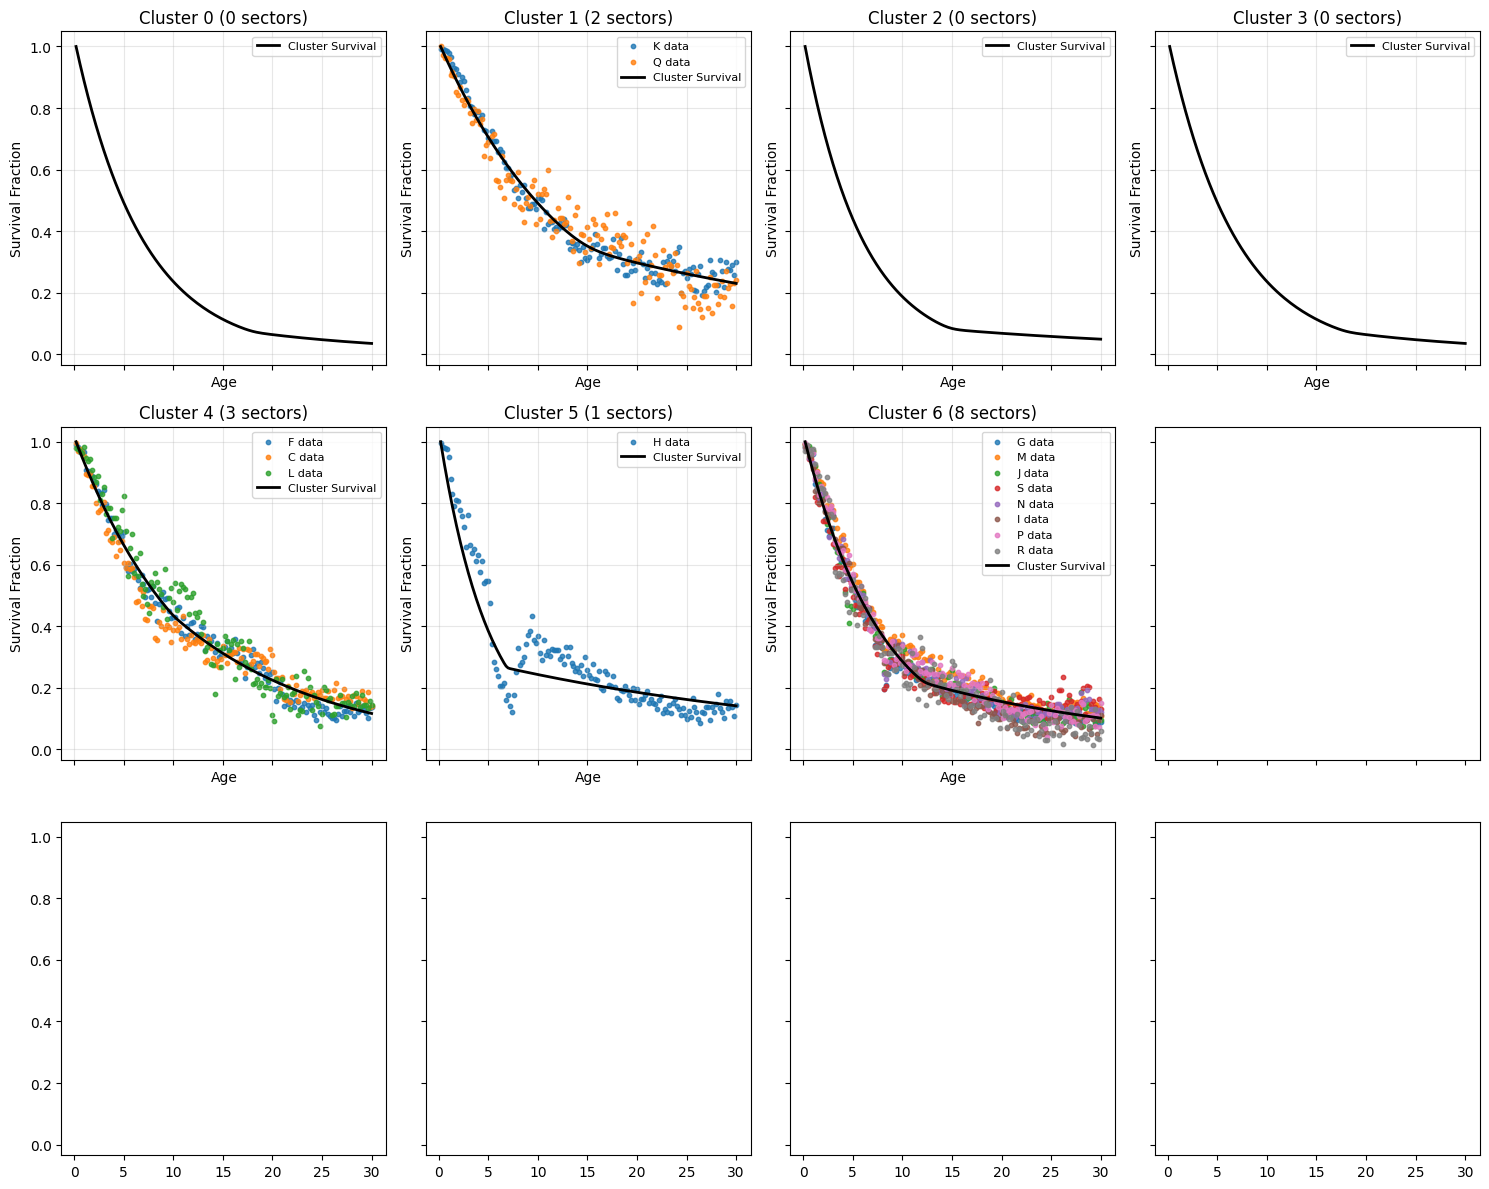

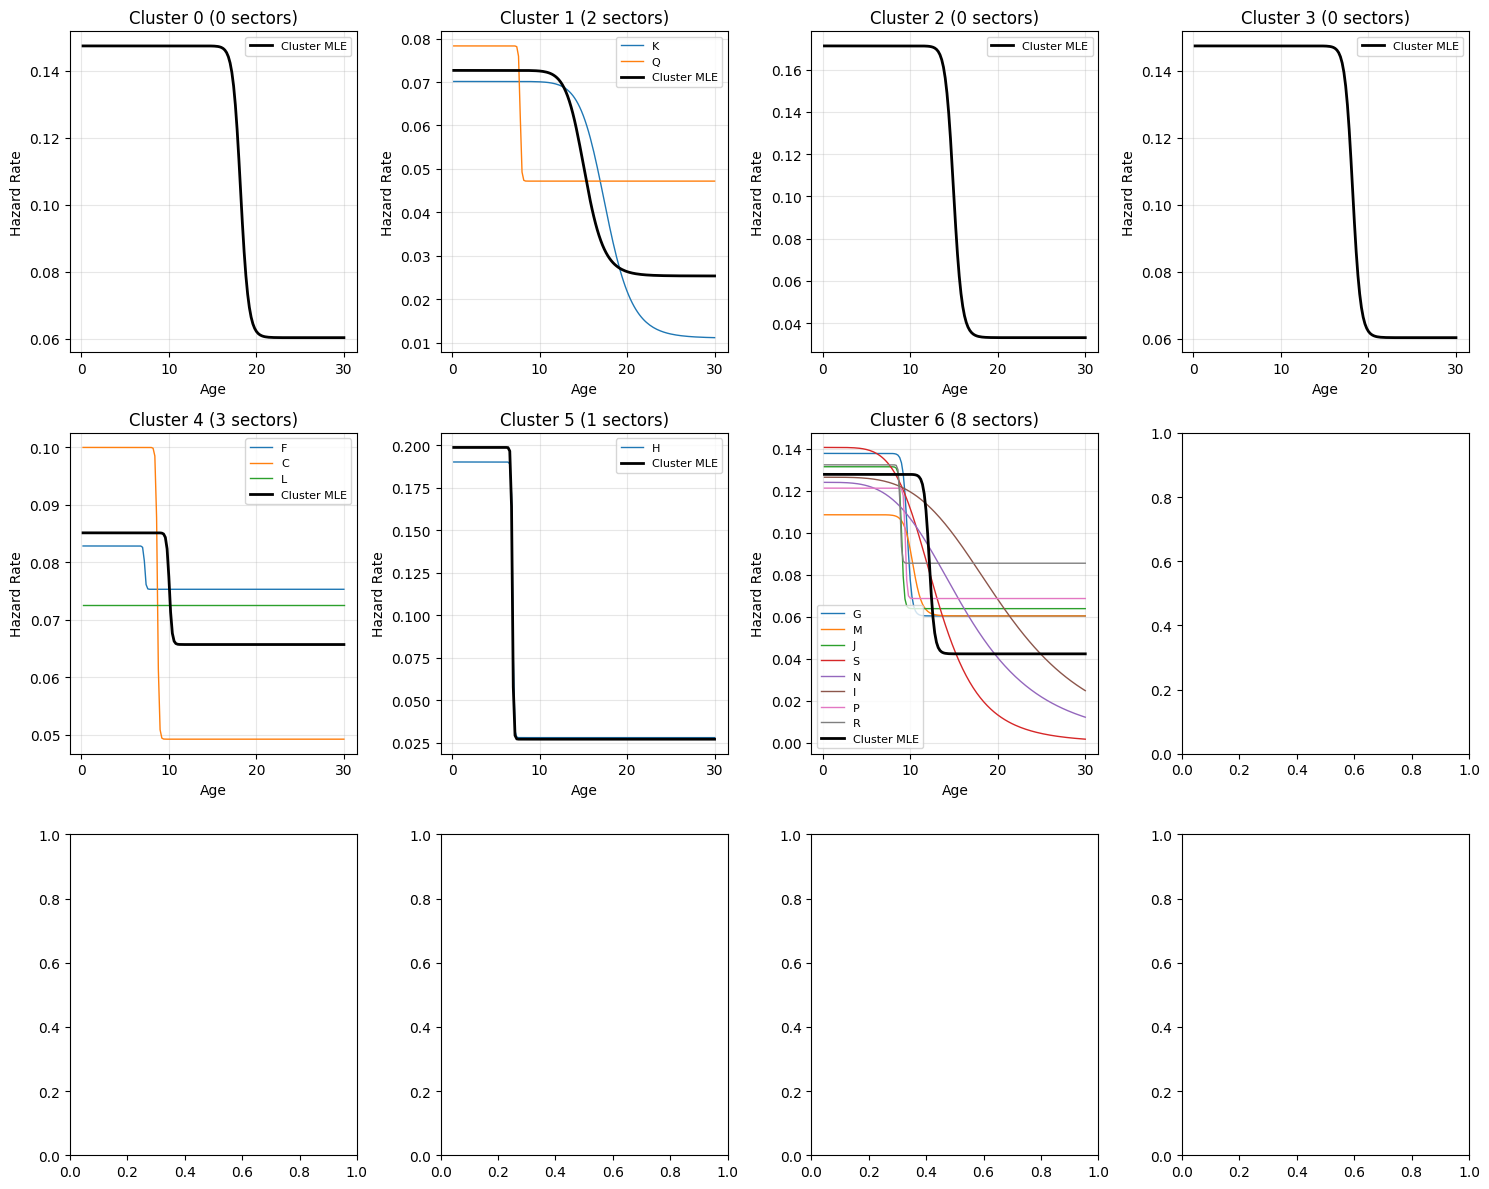

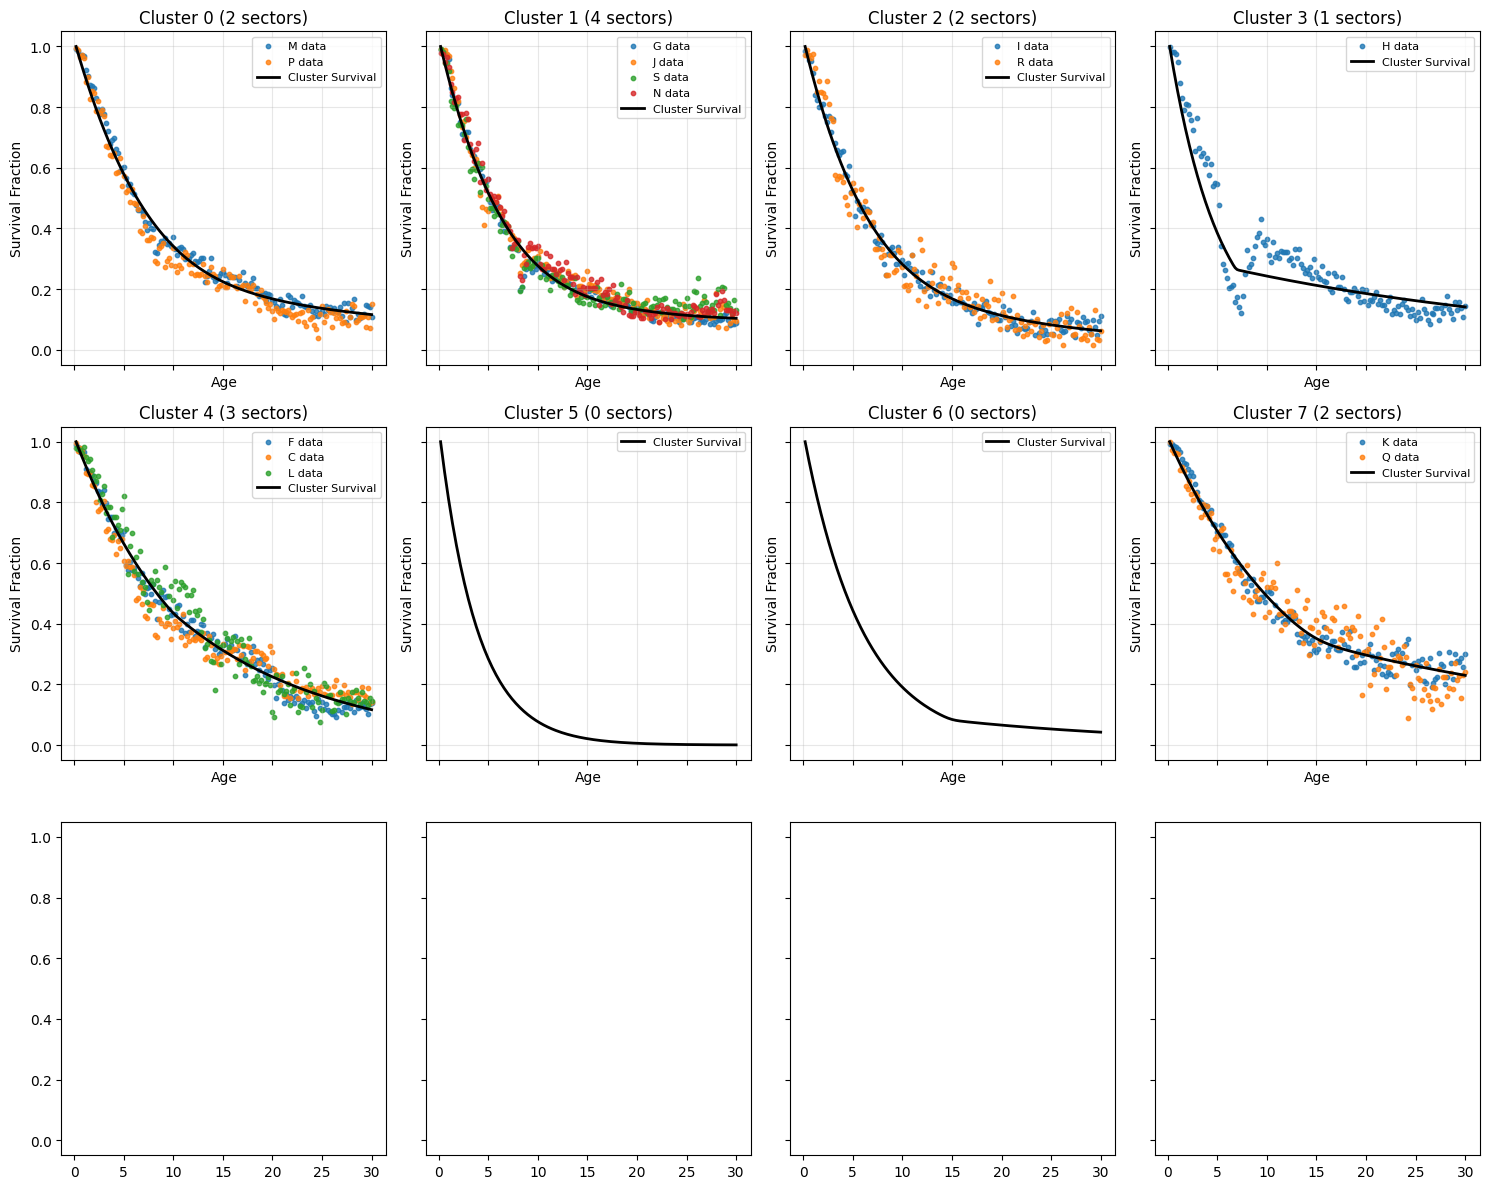

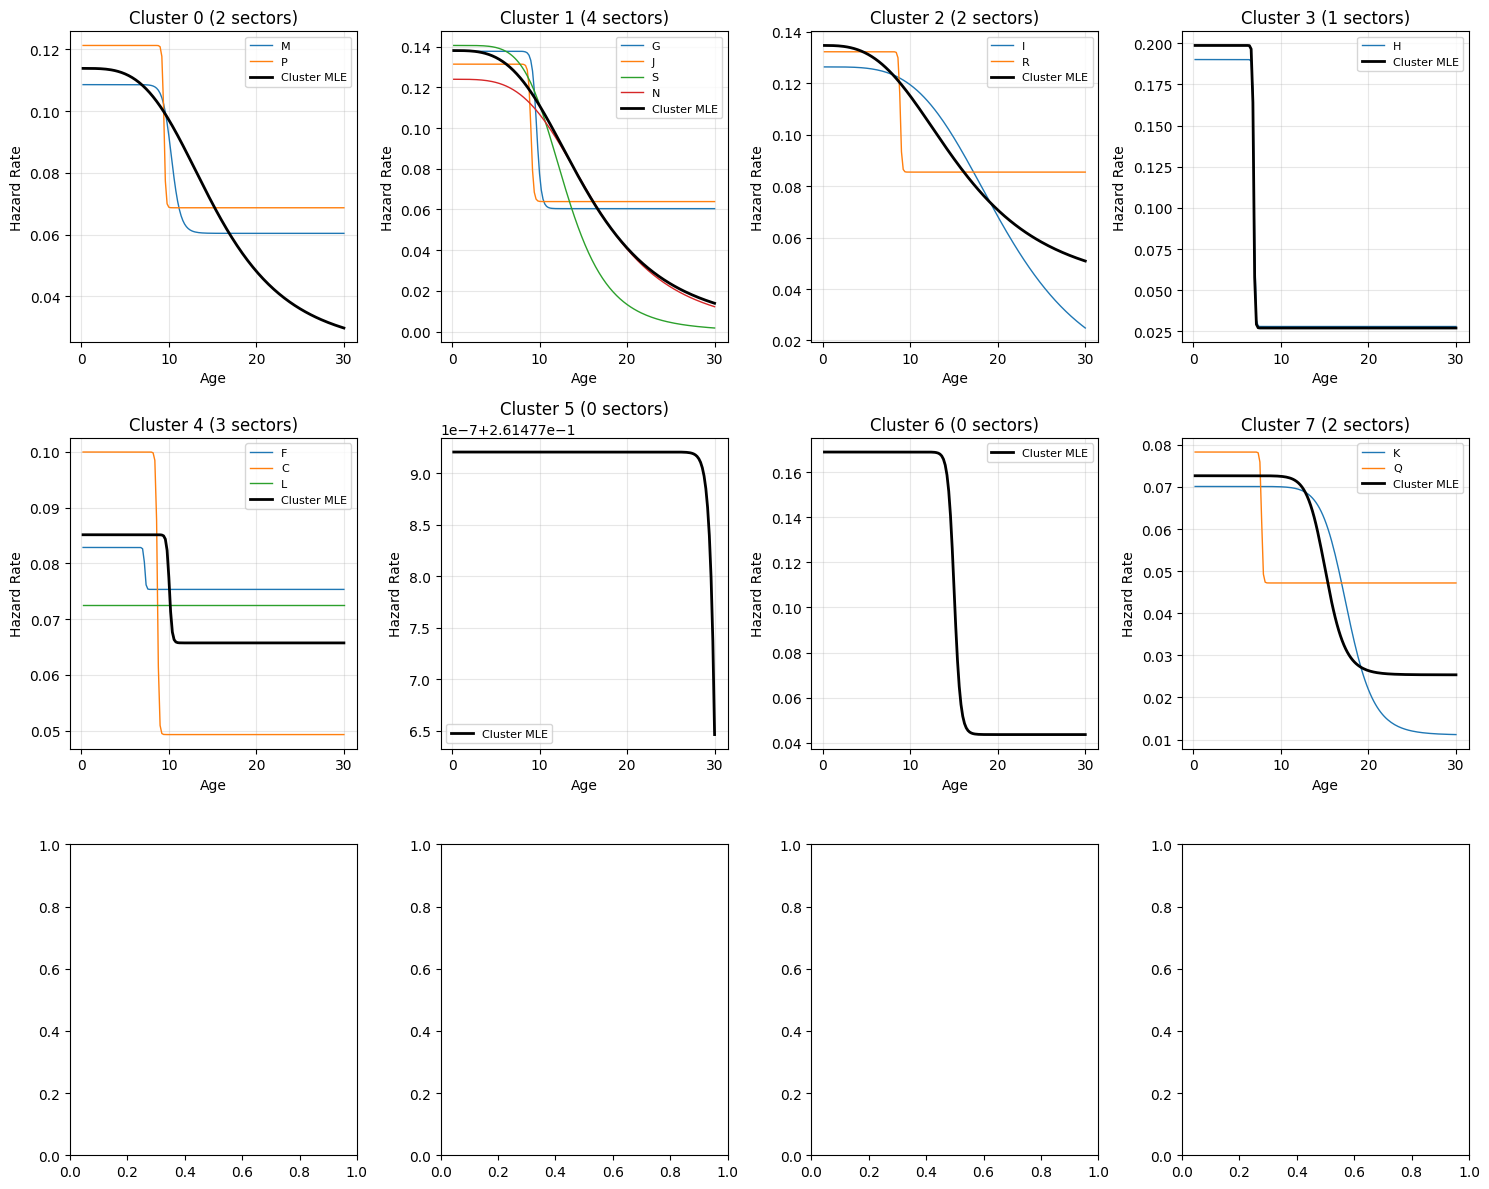

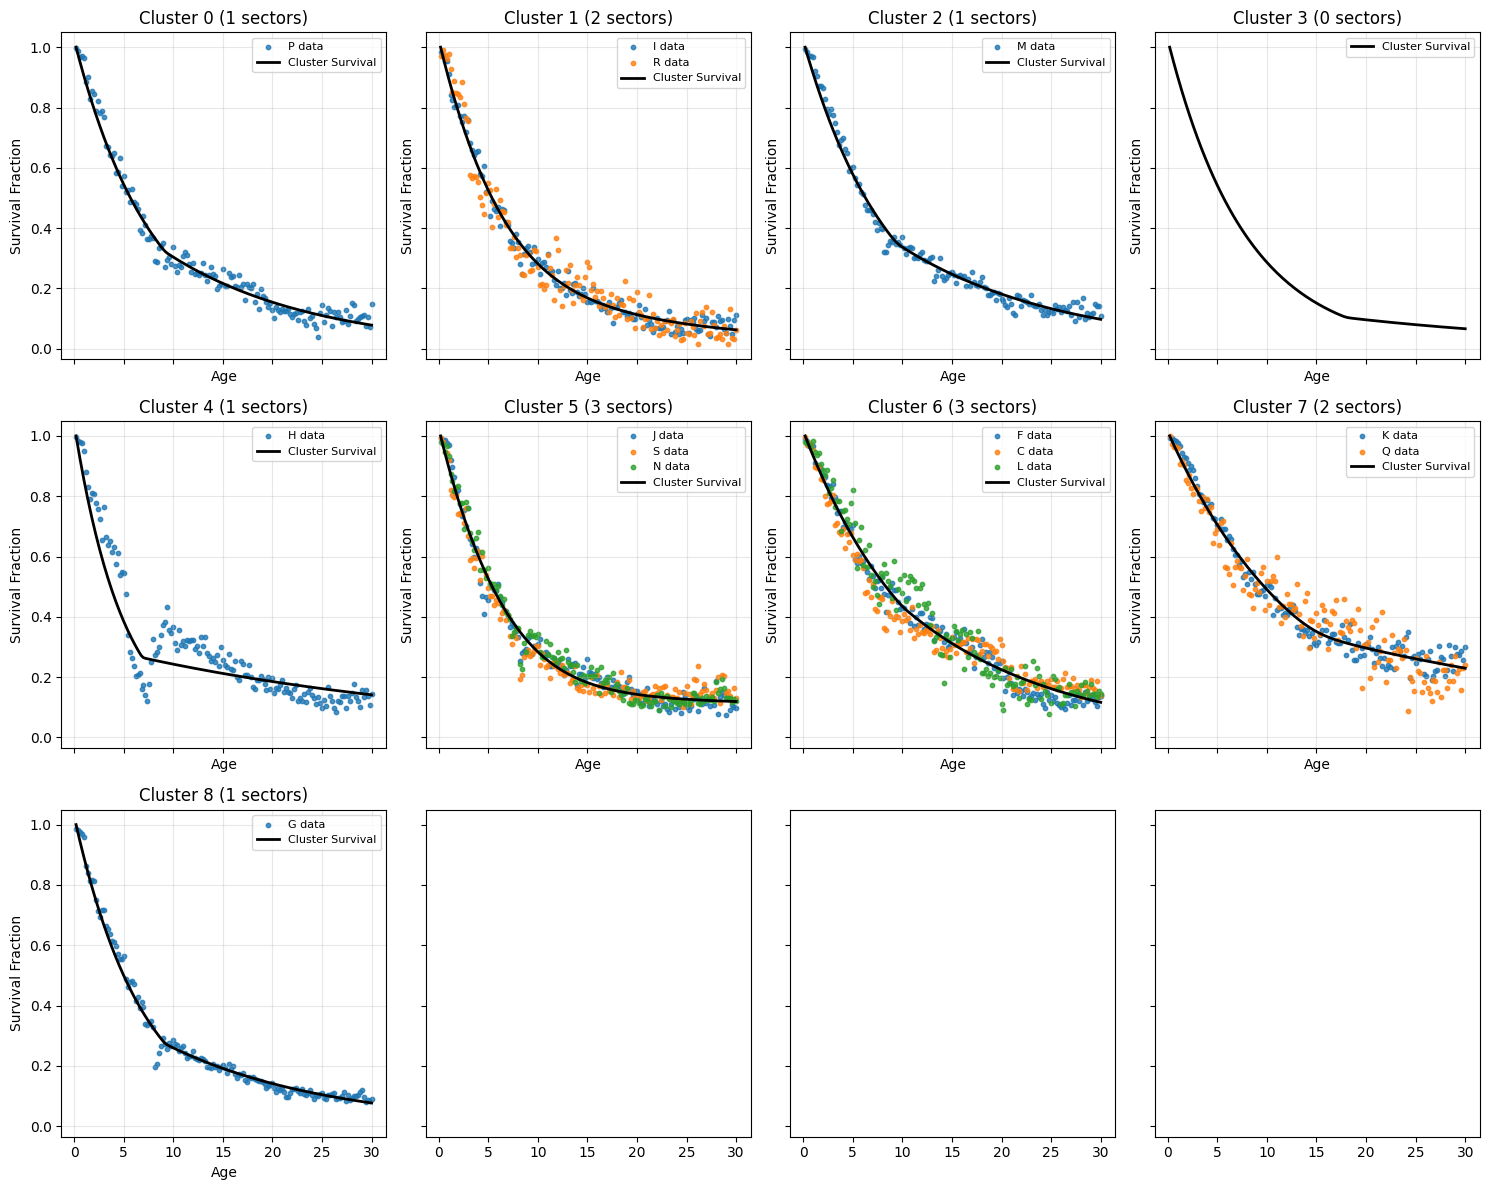

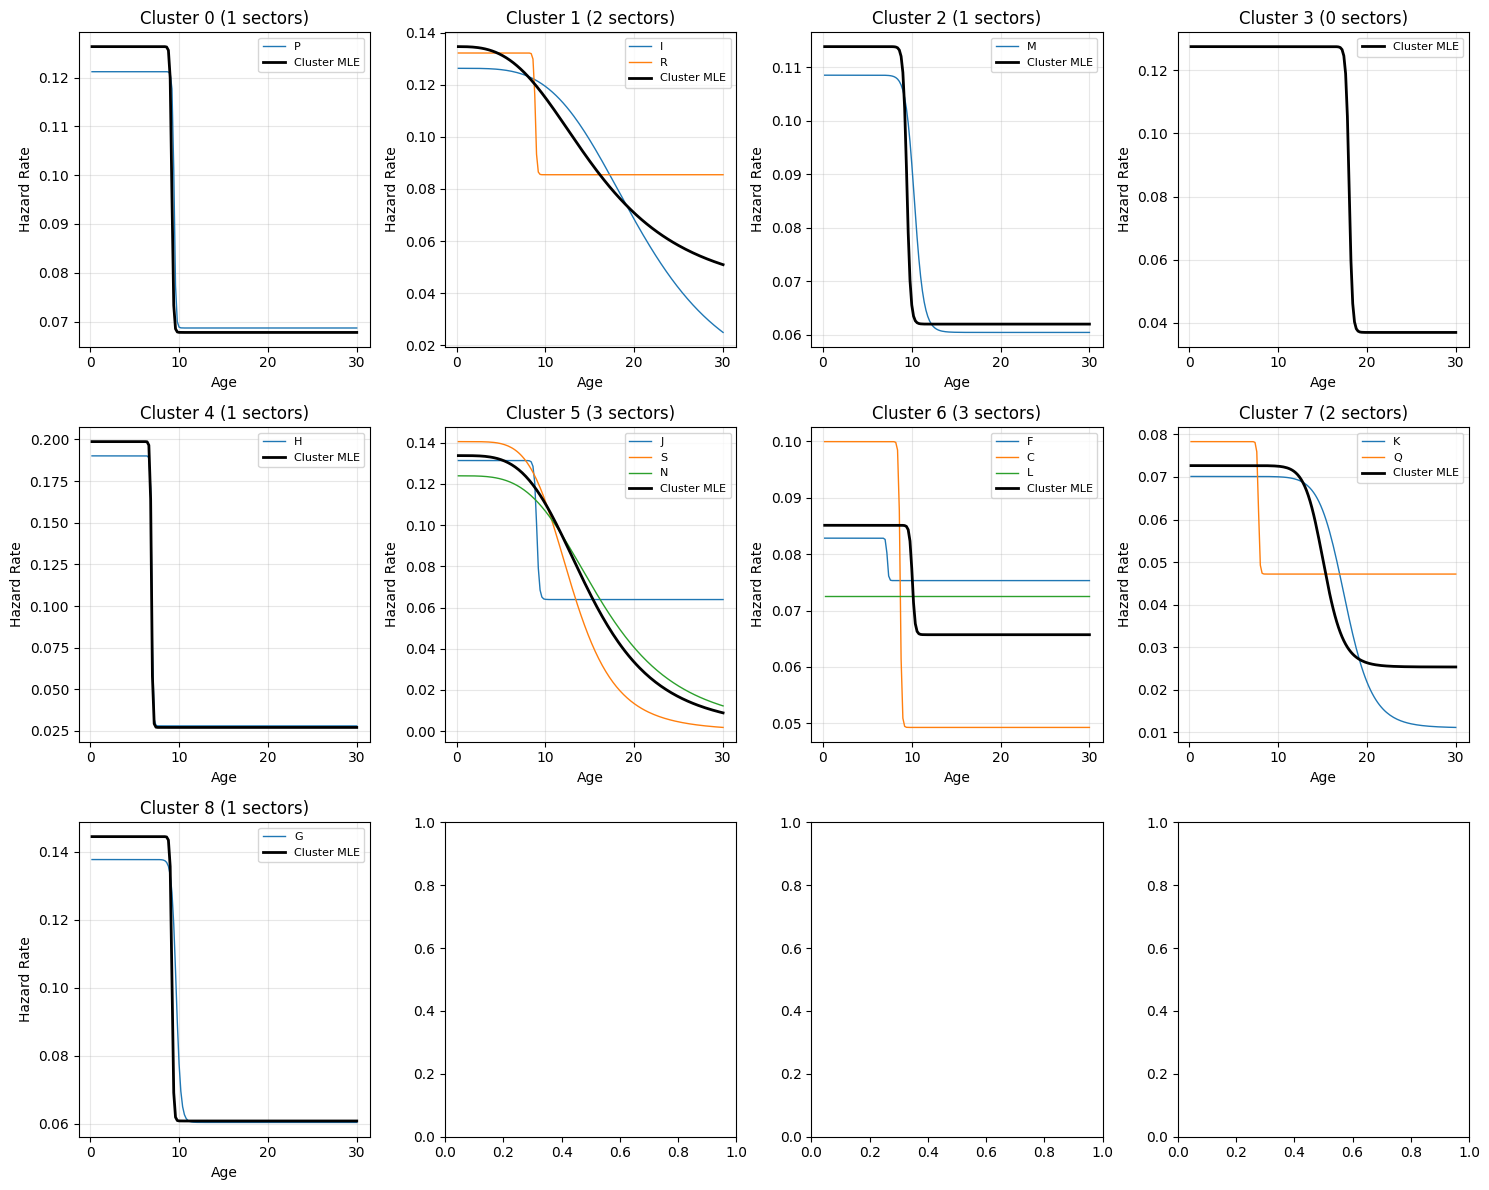

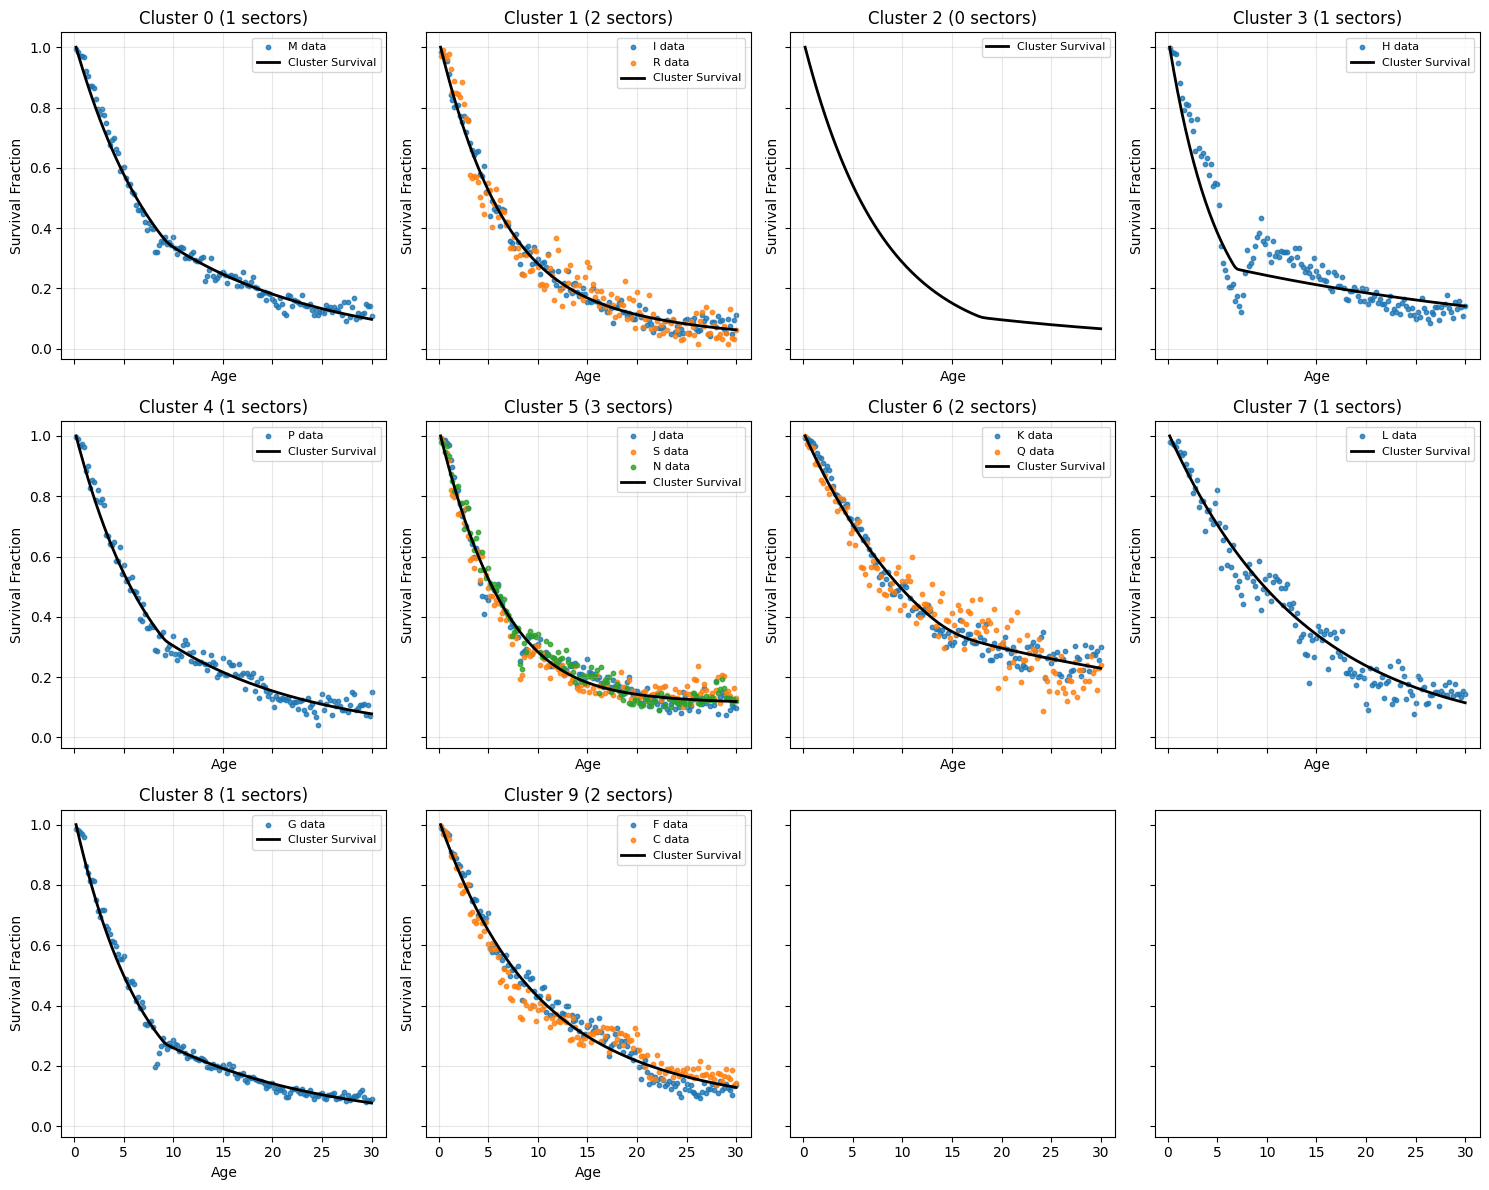

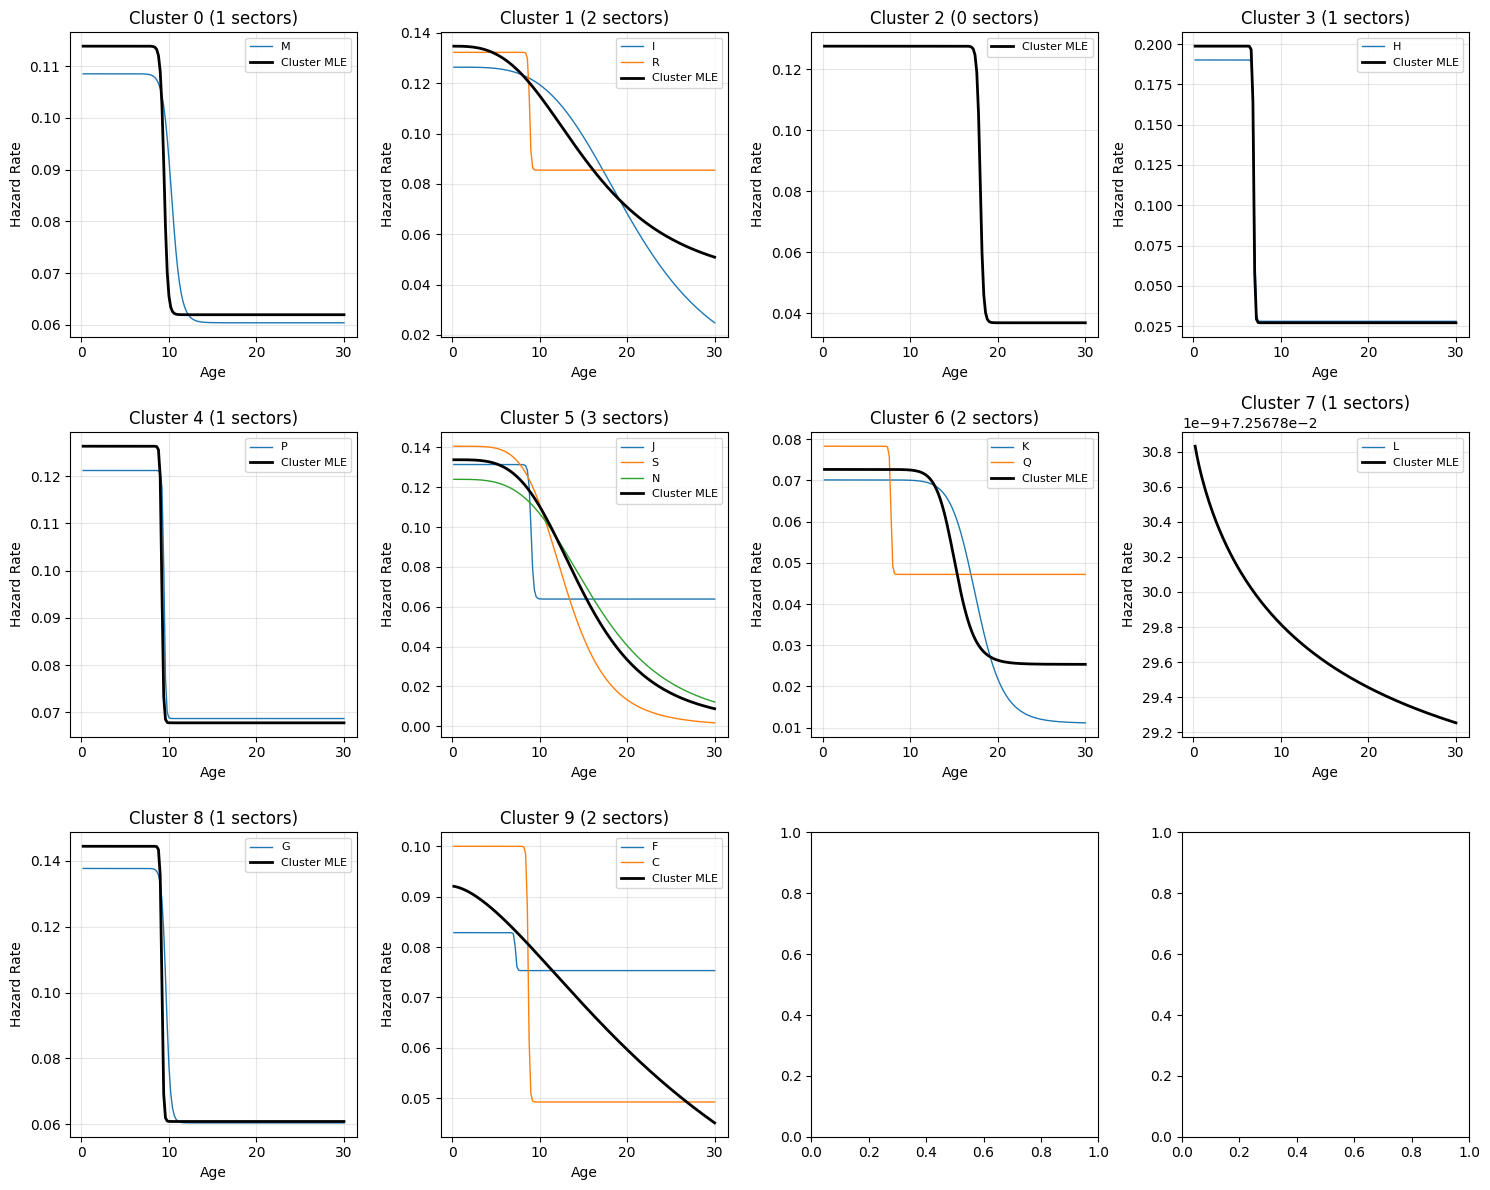

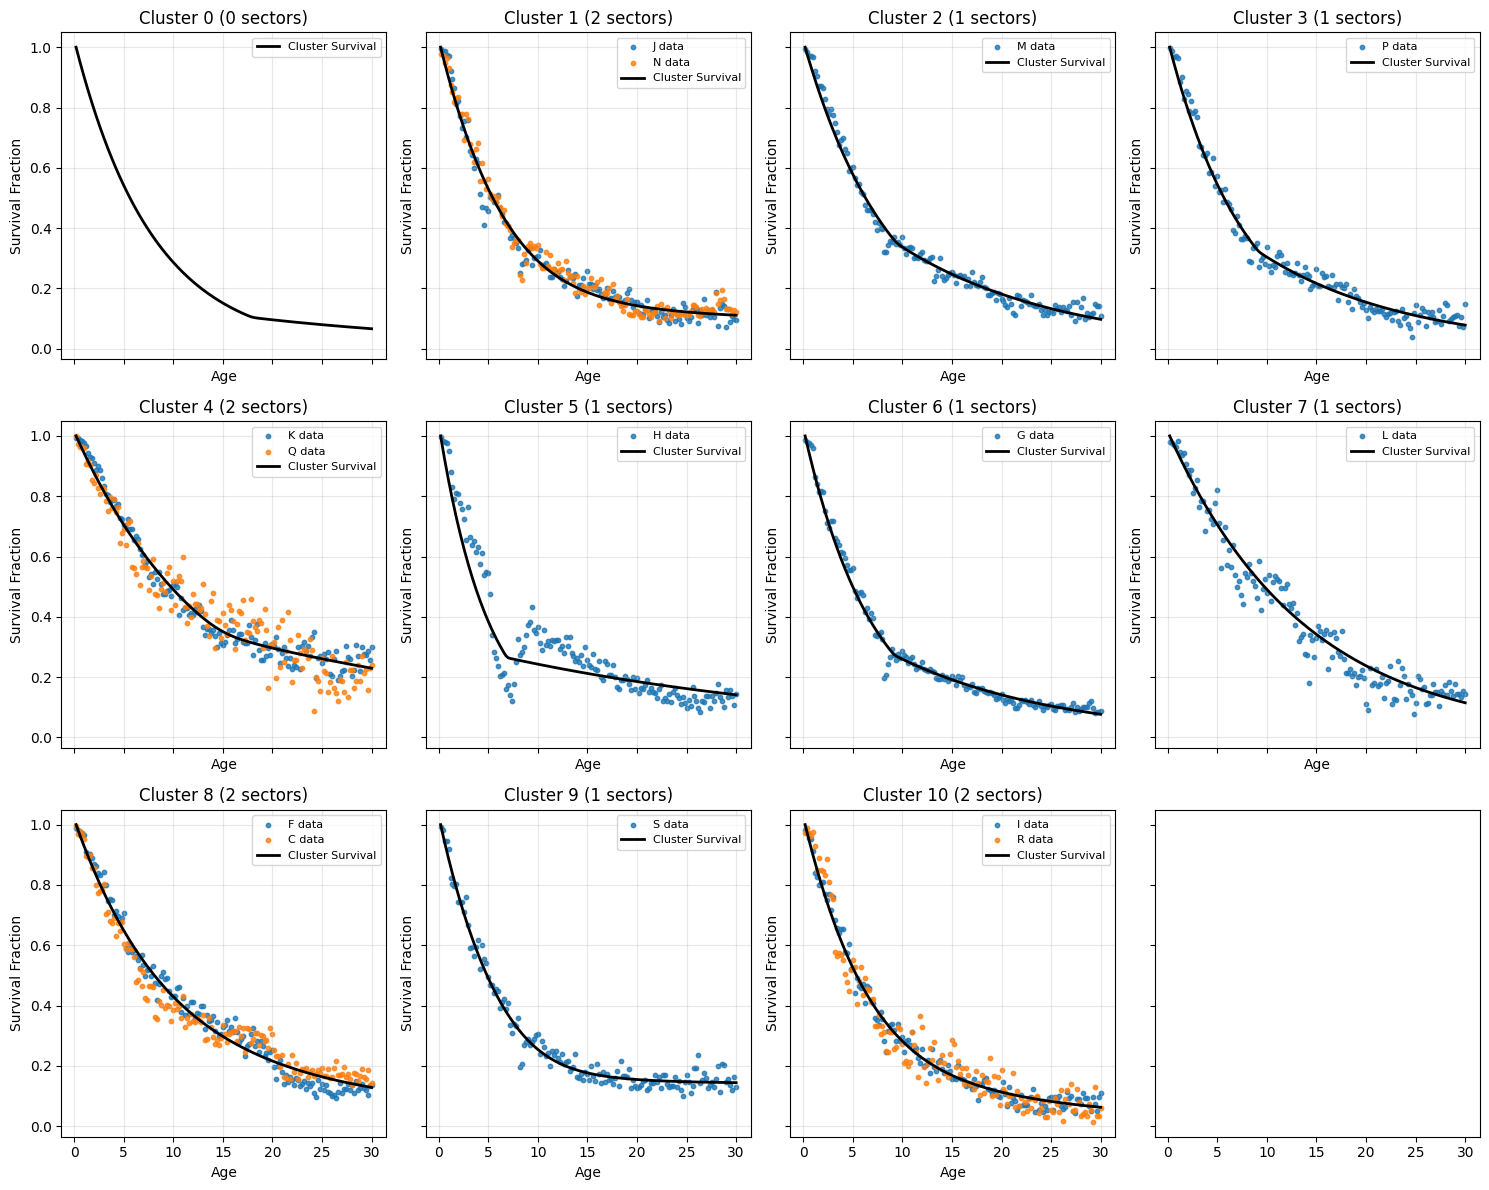

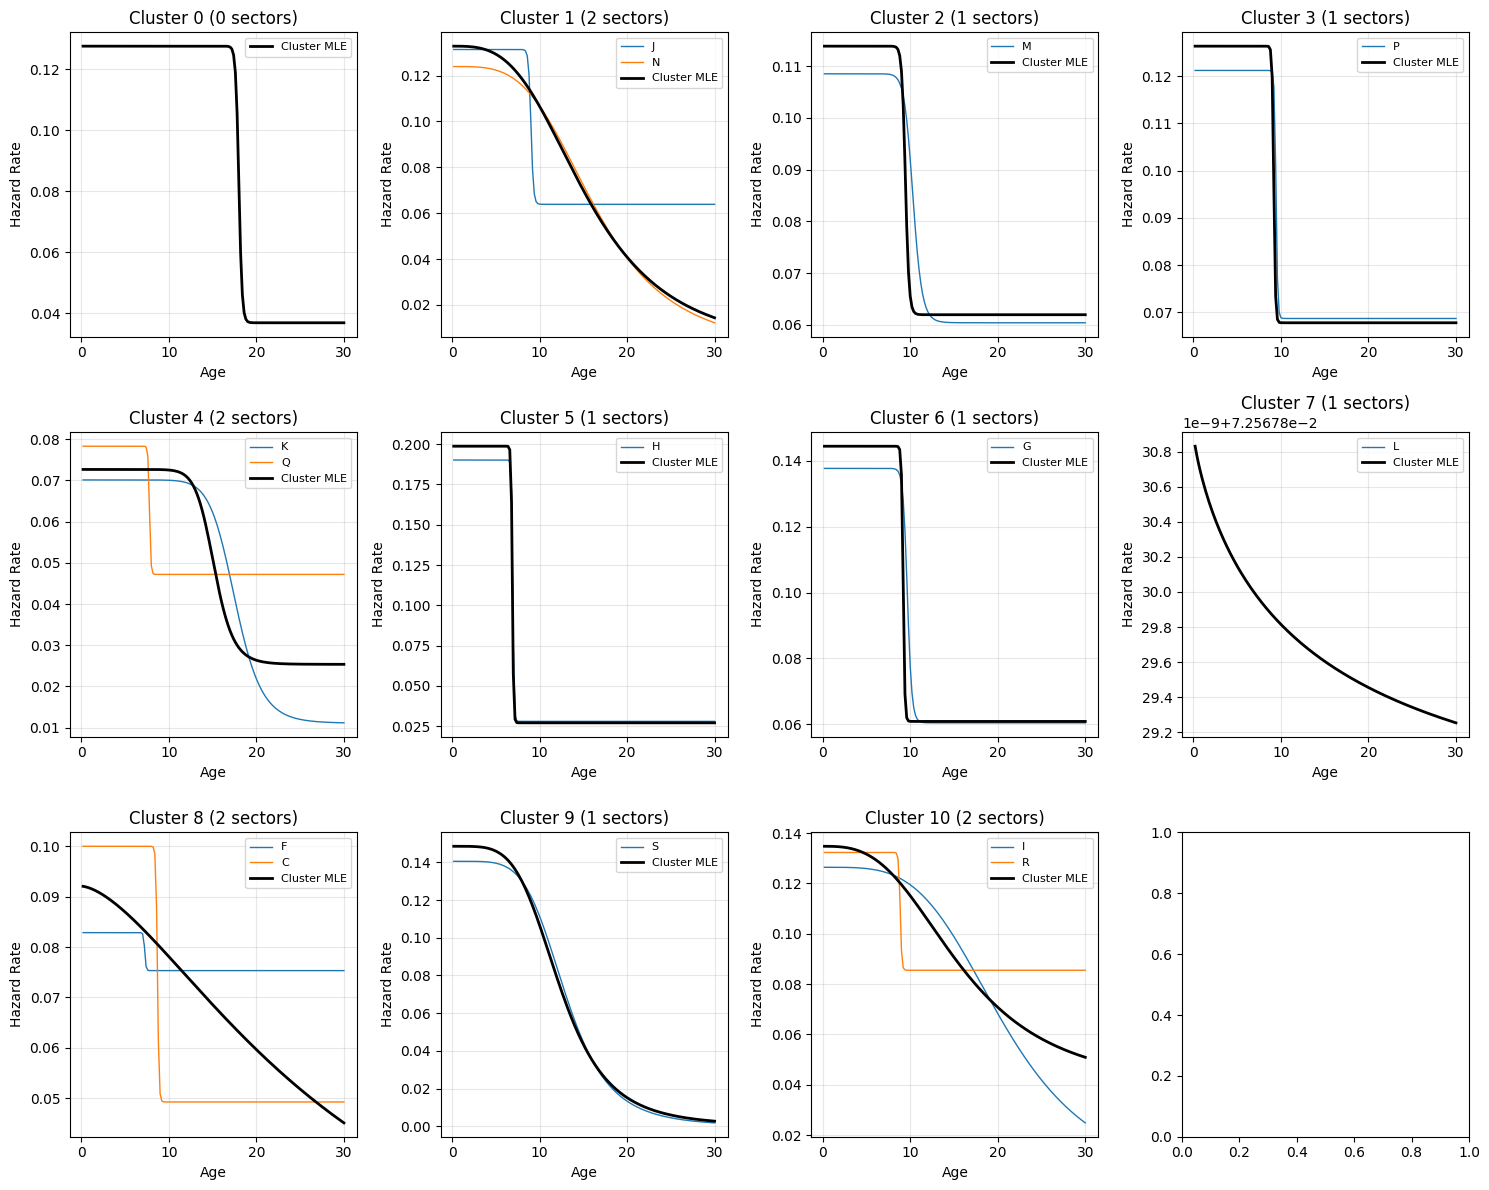

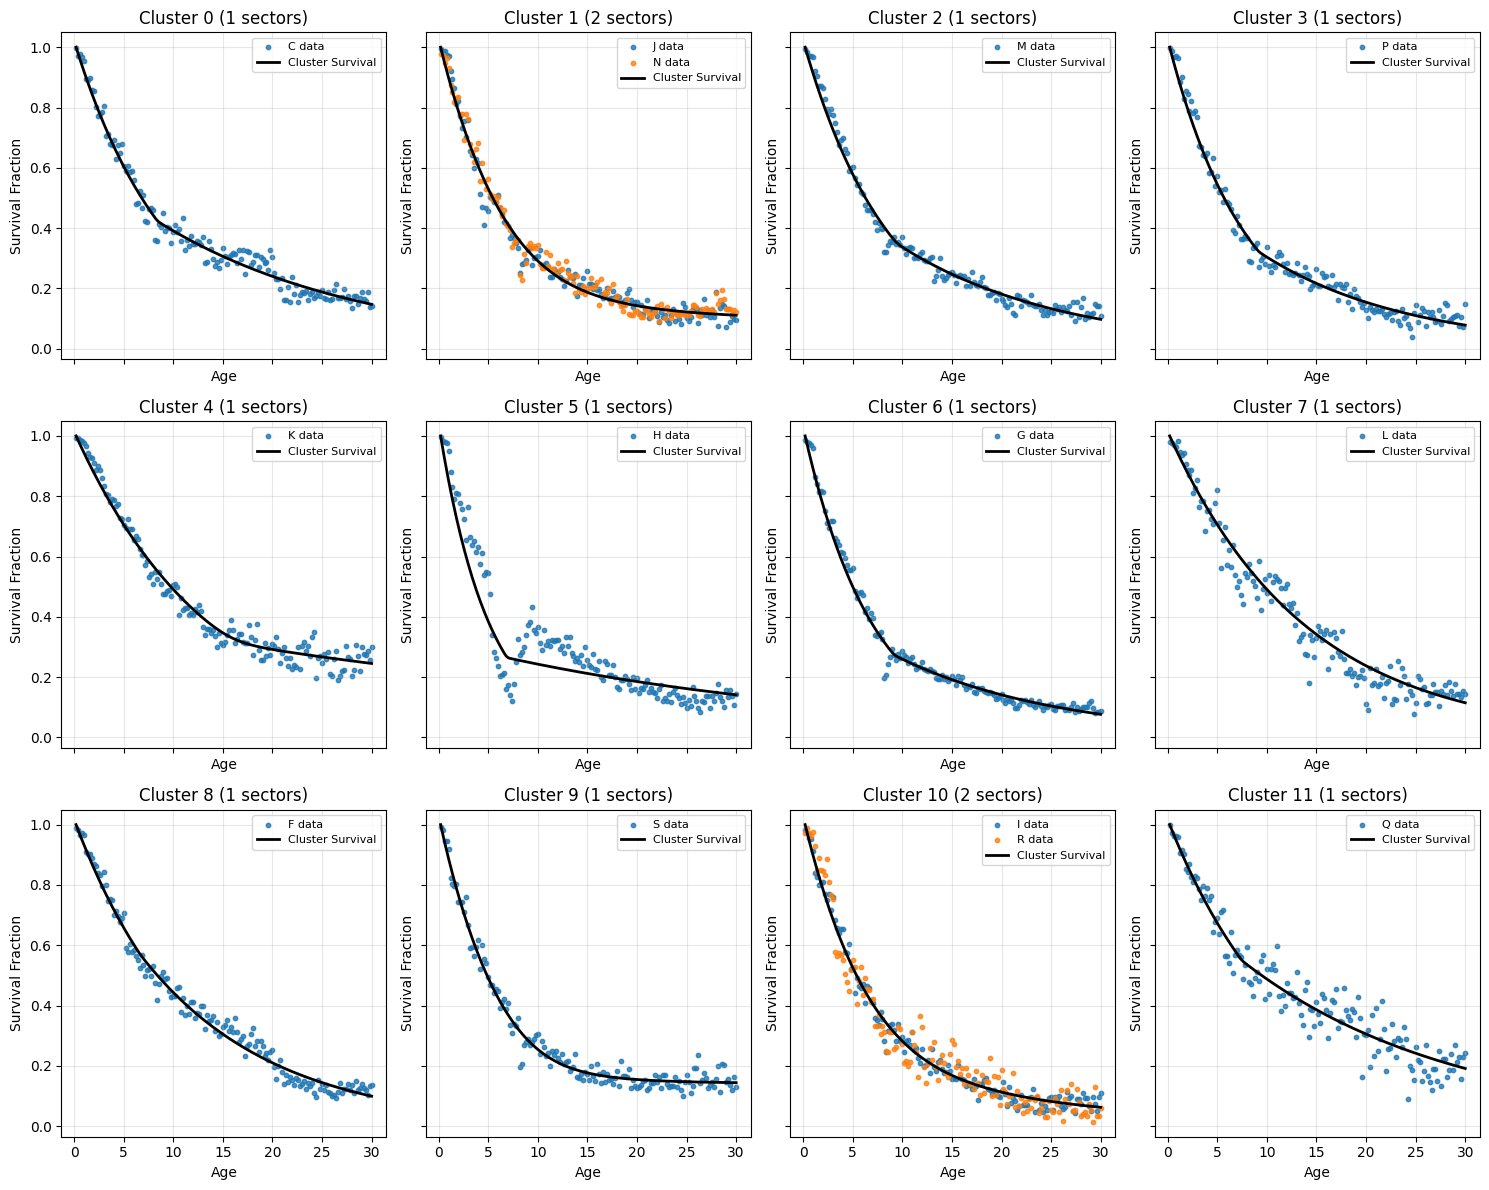

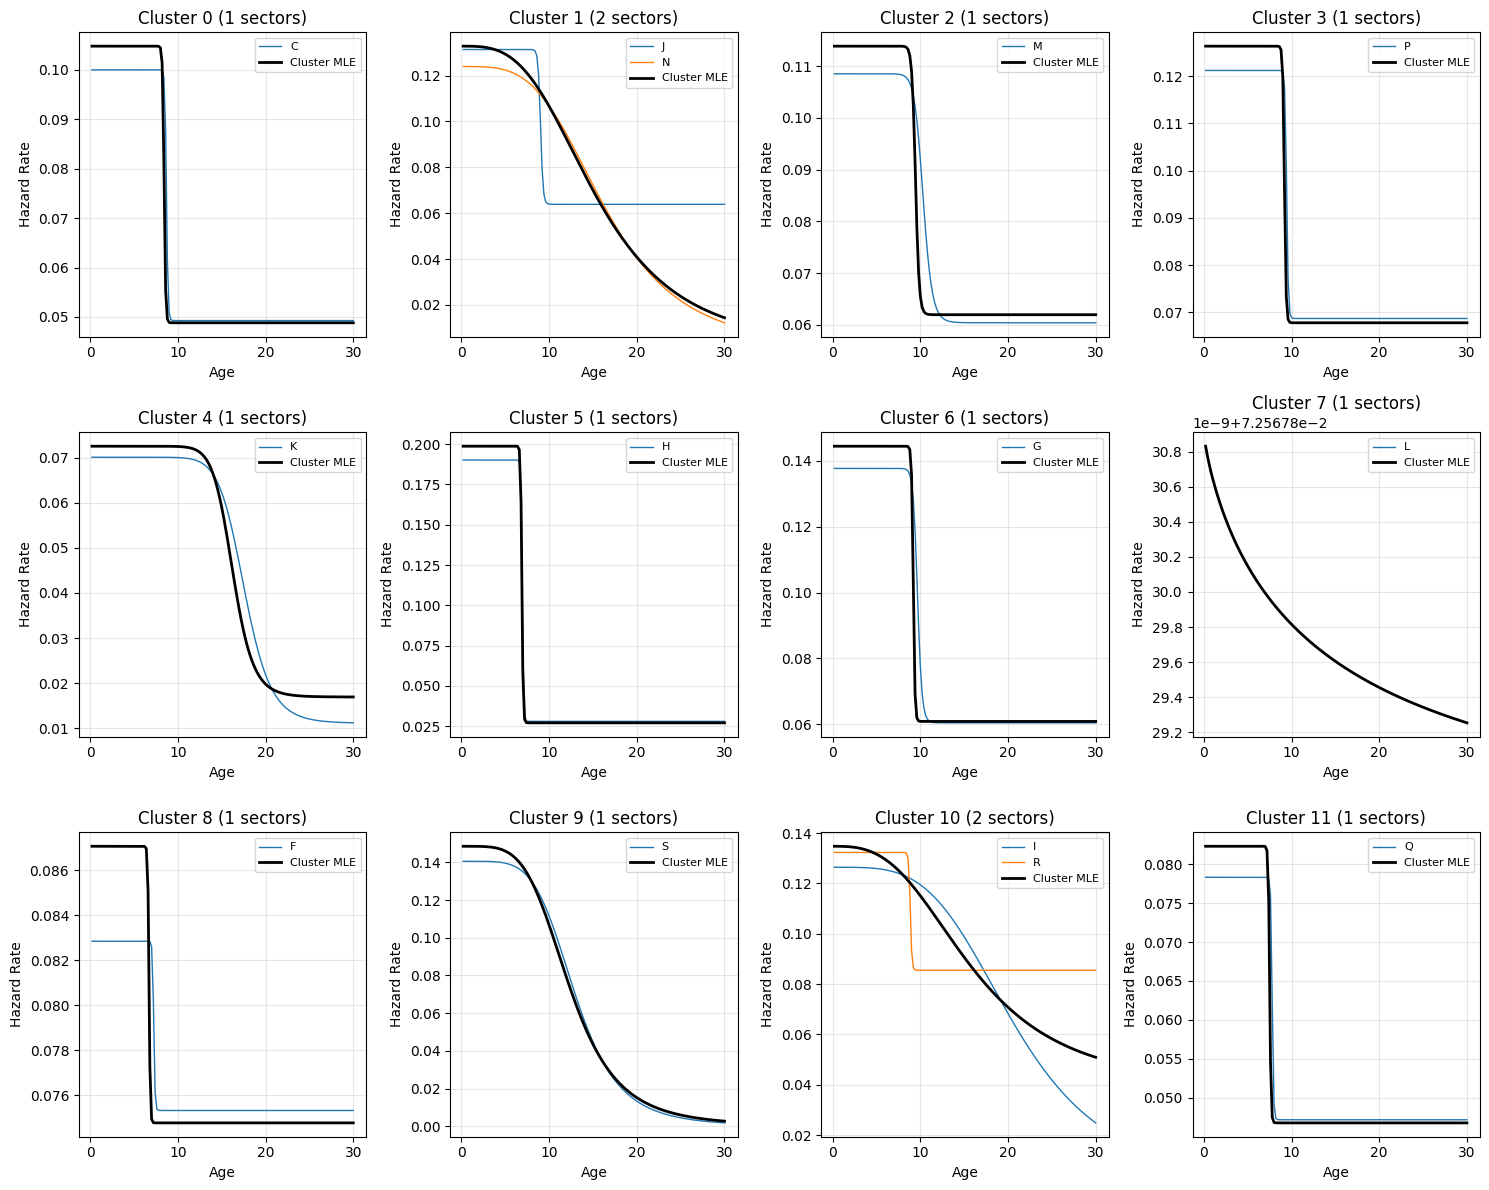

In [44]:
# Plot MLE against cluster data for 9 cluster model
for k in [4, 5, 6, 7, 8, 9, 10, 11, 12]:
    final_clusters = results[k]['clusters']
    final_params = results[k]['params']

    fig, axes = plt.subplots(3, 4, figsize=(15, 12), sharex=True, sharey=True)
    axes = axes.flatten()
    for cluster_id in range(k):
        # Get sectors in this cluster
        sectors_in_cluster = [sector_list[i] for i, c in enumerate(final_clusters) if c == cluster_id]
        cluster_params = final_params[cluster_id]
        ax = axes[cluster_id]
        # Plot observed data points for all sectors in the cluster
        for sector in sectors_in_cluster:
            obs = survival_data[sector]
            ax.scatter(ages_data, obs, s=10, alpha=0.8, label=f"{sector} data")
        # Plot cluster survival curve
        cluster_surv = fd.model_survival_curve_hill(ages_data, *cluster_params)
        ax.plot(ages_data, cluster_surv, 'k-', label='Cluster Survival', linewidth=2)
        ax.set_title(f"Cluster {cluster_id} ({len(sectors_in_cluster)} sectors)")
        ax.set_xlabel("Age")
        ax.set_ylabel("Survival Fraction")
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    fig, axes = plt.subplots(3, 4, figsize=(15, 12))
    axes = axes.flatten()
    for cluster_id in range(k):
        # Get sectors in this cluster
        sectors_in_cluster = [sector_list[i] for i, c in enumerate(final_clusters) if c == cluster_id]
        cluster_params = final_params[cluster_id]
        ax = axes[cluster_id]
        # Plot MLE hill function for each sector in the cluster
        for sector in sectors_in_cluster:
            sector_params = df_params.loc[sector].values
            sector_curve = fd.hill_hazard(ages_data, *sector_params)
            ax.plot(ages_data, sector_curve, alpha=1, label=f"{sector}", linewidth=1)
        # Plot cluster MLE hill function
        cluster_curve = fd.hill_hazard(ages_data, *cluster_params)
        ax.plot(ages_data, cluster_curve, 'k-', label='Cluster MLE', linewidth=2)
        ax.set_title(f"Cluster {cluster_id} ({len(sectors_in_cluster)} sectors)")
        ax.set_xlabel("Age")
        ax.set_ylabel("Hazard Rate")
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [ ]:
from scipy.stats import chi2

sector_list = ['G', 'M', 'F', 'J', 'K', 'C', 'H', 'S', 'N', 'I', 'P', 'L', 'Q', 'R']
parameters = [
    [0.13771959172635478, 0.06036883390826407, 9.683527817633134, 37.16554776246212], 
    [0.10853423852842373, 0.06040203094166163, 10.324655252053779, 20.2431022135619], 
    [0.08284949629045338, 0.07532170024242305, 7.246072550255881, 99.9995683704219], 
    [0.13138419047680286, 0.06388417019228498, 9.027011437441391, 63.20559648903392], 
    [0.07012004488933721, 0.011080713775644365, 17.599335895302804, 11.726782536983189], 
    [0.09997597066599069, 0.049270691945483475, 8.699132957275232, 100.0], 
    [0.19014425302275023, 0.02801565370451772, 6.937673733970917, 100.0], 
    [0.14057209547880267, 1.0000000076278874e-10, 12.954253262292541, 5.19908018295204], 
    [0.12396232834152839, 1e-10, 16.432702180468965, 3.6763918799521744], 
    [0.12639658719104133, 1.0000000249470075e-10, 20.851108767628933, 3.8694205399833757], 
    [0.1212132957507885, 0.06868421106599219, 9.445203344625348, 100.0], 
    [0.07305173006148806, 0.07305173006148806, 4.686889369376459, 49.86003240187913], 
    [0.07830160011697058, 0.047197607271208426, 7.792050676547918, 100.0], 
    [0.13228889671445893, 0.0854858990969846, 8.857658026221204, 100.0]
    ]

# Convert to DataFrame
df_params = pd.DataFrame(parameters, 
                        columns=['mu_ub', 'mu_lb', 'K', 'm'],
                        index=sector_list)

def hill_hazard(a, mu_ub, mu_lb, K, m):
    return mu_ub - (mu_ub - mu_lb) * (a**m) / (a**m + K**m + 1e-10)

def hill_survival_function(a, mu_ub, mu_lb, K, m):
    result, _ = quad(lambda s: hill_hazard(s, mu_ub, mu_lb, K, m), 0, a)
    return np.exp(-result)

def model_survival_curve_hill(ages, mu_ub, mu_lb, K, m):
    return np.array([hill_survival_function(a, mu_ub, mu_lb, K, m) for a in ages])

# Load actual survival data - FIXED: Get consistent ages_data
survival_data = {}
ages_data = None  # Initialize to store consistent age bins

for i, sector in enumerate(sector_list):
    survival_fractions, ages = fd.obtain_survival_fractions(df_analysis, 'Sector', sector)
    survival_data[sector] = survival_fractions
    
    # Use the first sector's ages as reference for all sectors
    if i == 0:
        ages_data = ages

print(f"Using age bins from 0 to {max(ages_data):.1f} years with {len(ages_data)} bins")

def log_likelihood(params, ages, survivors, totals):
    mu_ub, mu_lb, K, m = params
    if mu_lb < 0 or mu_ub < mu_lb or K <= 0 or m <= 0:
        return -np.inf

    S_vals = model_survival_curve_hill(ages, mu_ub, mu_lb, K, m)
    S_vals = np.clip(S_vals, 1e-12, 1 - 1e-12)

    deaths = totals - survivors
    logL = np.sum(survivors * np.log(S_vals) + deaths * np.log(1 - S_vals))
    return logL

def likelihood_ratio_test_between_sectors(sector1, sector2):
    # Get data for each sector
    totals1, survivors1 = fd.obtain_total_alive_count(df_analysis, 'Sector', sector1)
    totals2, survivors2 = fd.obtain_total_alive_count(df_analysis, 'Sector', sector2)
    valid1 = totals1 > 0
    valid2 = totals2 > 0
    ages1 = ages_data[:len(survivors1[valid1])]
    ages2 = ages_data[:len(survivors2[valid2])]

    # H0: Fit both sectors together (4 shared parameters)    
    def neg_logL1(params):
        ll1 = log_likelihood(params[:4], ages1, survivors1[valid1], totals1[valid1])
        ll2 = log_likelihood(params[4:], ages2, survivors2[valid2], totals2[valid2])
        return -(ll1 + ll2)
    # Initial guess: concatenate from df_params
    initial_guess = np.concatenate([df_params.loc[sector1].values, df_params.loc[sector2].values])
    bounds = [(1e-6, 0.3), (1e-10, 0.15), (0.1, 100.0), (0.1, 100.0)] * 2
    constraints = ({'type': 'ineq', 'fun': lambda x: x[0] - x[1]},  # mu_ub >= mu_lb for sector1
                   {'type': 'ineq', 'fun': lambda x: x[4] - x[5]})  # mu_ub >= mu_lb for sector2
    res1 = minimize(neg_logL1, initial_guess, bounds=bounds, constraints = constraints)
    ll1 = -res1.fun

    # H1: Fit each sector separately (8 parameters: 4 per sector)
    combined_ages = np.concatenate([ages1, ages2])
    combined_survivors = np.concatenate([survivors1[valid1], survivors2[valid2]])
    combined_totals = np.concatenate([totals1[valid1], totals2[valid2]])
    def neg_logL2(params):
        return -log_likelihood(params, combined_ages, combined_survivors, combined_totals)
    initial_guess2 = np.mean([df_params.loc[sector1].values, df_params.loc[sector2].values], axis=0)
    bounds2 = [(1e-6, 0.3), (1e-10, 0.15), (0.1, 100.0), (0.1, 100.0)]
    res2 = minimize(neg_logL2, initial_guess2, bounds=bounds2, constraints = ({'type': 'ineq', 'fun': lambda x: x[0] - x[1]}))
    ll2 = -res2.fun

    # Likelihood ratio statistic
    LR = 2 * (ll1 - ll2)
    df = 4  # difference in number of parameters
    p_value = chi2.sf(LR, df)

    # print(f"Sector1: {sector1}, Sector2: {sector2}")
    # print(f"  LogL (separate): {ll1:.2f}")
    # print(f"  LogL (shared):   {ll2:.2f}")
    # print(f"  LR statistic:    {LR:.2f}")
    # print(f"  p-value:         {p_value:.4g}")

    return {
        'sector1': sector1,
        'sector2': sector2,
        'logL_separate': ll1,
        'logL_shared': ll2,
        'LR_stat': LR,
        'df': df,
        'p_value': p_value,
        'params_separate': res1.x,
        'params_shared': res2.x
    }

pval_df = pd.DataFrame(index=sector_list, columns=sector_list, dtype=float)

for i, sector1 in enumerate(sector_list):
    for j, sector2 in enumerate(sector_list):
        if i == j:
            pval_df.loc[sector1, sector2] = np.nan
        elif i < j:
            result = likelihood_ratio_test_between_sectors(sector1, sector2)
            pval_df.loc[sector1, sector2] = round(result['p_value'], 3)
        else:
            pval_df.loc[sector1, sector2] = np.nan

print("Pairwise sector p-values (rounded to 3dp):")
print(pval_df)

Using age bins from 0 to 30.0 years with 150 bins
Pairwise sector p-values (rounded to 3dp):
     G    M    F    J    K    C    H    S    N    I    P    L    Q    R
G  NaN  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0
M  0.0  NaN  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0
F  0.0  0.0  NaN  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0
J  0.0  0.0  0.0  NaN  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0
K  0.0  0.0  0.0  0.0  NaN  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0
C  0.0  0.0  0.0  0.0  0.0  NaN  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0
H  0.0  0.0  0.0  0.0  0.0  0.0  NaN  0.0  0.0  0.0  0.0  0.0  0.0  0.0
S  0.0  0.0  0.0  0.0  0.0  0.0  0.0  NaN  0.0  0.0  0.0  0.0  0.0  0.0
N  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  NaN  0.0  0.0  0.0  0.0  0.0
I  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  NaN  0.0  0.0  0.0  0.0
P  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  NaN  0.0  0.0  0.0
L  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  